In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import platform

# 운영체제별 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumGothic')

# 마이너스 부호 깨짐 해결
plt.rcParams['axes.unicode_minus'] = False    

In [57]:
df = pd.read_csv('data/real_estate_clean_v2.csv', encoding='cp949')
df

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_98926/1714618046.py:1: DtypeWarning: Columns (12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_clean_v2.csv', encoding='cp949')


,Unnamed: 0.1,Unnamed: 0,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,...,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,QUARTER,QUARTER_INT,CTRT_BLDG_AGE,AMT_PER_AREA,AMT_PER_PYEONG
0,0,14,11530,구로구,10800,오류동,NaN,2018-12-31,73000,197.40,...,NaN,1990,단독다가구,NaN,2018,2018Q4,12,28,369.807497,1222.509625
1,1,16,11215,광진구,10100,중곡동,NaN,2018-12-31,102000,89.09,...,NaN,1973,단독다가구,NaN,2018,2018Q4,12,45,1144.909642,3784.842294
2,2,43,11560,영등포구,10900,영등포동8가,NaN,2018-12-29,88700,36.36,...,NaN,1945,단독다가구,NaN,2018,2018Q4,12,73,2439.493949,8064.479098
3,3,87,11230,동대문구,10900,휘경동,NaN,2018-12-28,95000,140.22,...,NaN,1991,단독다가구,NaN,2018,2018Q4,12,27,677.506775,2239.701897
4,4,92,11620,관악구,10200,신림동,NaN,2018-12-27,56500,179.46,...,NaN,1988,단독다가구,NaN,2018,2018Q4,12,30,314.833389,1040.776218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777302,777302,833566,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,...,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777303,777303,833567,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,...,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777304,777304,833568,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,...,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777305,777305,833569,11650,서초구,10800,서초동,벨라채 오피스텔,2023-12-04,24000,36.64,...,NaN,2003,오피스텔,중개거래,2023,2023Q4,12,20,655.021834,2165.371179


In [58]:
# 건물용도별 분기별 평균 거래금액 데이터
amt_quarter = df.groupby(['BLDG_USG','QUARTER'], as_index=False)['THING_AMT'].mean() 
amt_quarter

,BLDG_USG,QUARTER,THING_AMT
0,단독다가구,2018Q1,91660.798444
1,단독다가구,2018Q2,92758.539540
2,단독다가구,2018Q3,93805.797301
3,단독다가구,2018Q4,95224.964023
4,단독다가구,2019Q1,100308.318792
...,...,...,...
103,오피스텔,2023Q3,23919.721700
104,오피스텔,2023Q4,23773.809395
105,오피스텔,2024Q1,29124.316085
106,오피스텔,2024Q2,24922.032837


In [59]:
# 건물용도별로 나누어 분기별 건물가격 확인
dan = amt_quarter[amt_quarter['BLDG_USG']=='단독다가구'].copy()
apt = amt_quarter[amt_quarter['BLDG_USG']=='아파트'].copy()
yeon = amt_quarter[amt_quarter['BLDG_USG']=='연립다세대'].copy()
off = amt_quarter[amt_quarter['BLDG_USG']=='오피스텔'].copy()

In [60]:
# 건물용도별 분기별 평균 평당가 데이터
ppp_quarter = df.groupby(['BLDG_USG','QUARTER'], as_index=False)['AMT_PER_PYEONG'].mean() 
ppp_quarter

,BLDG_USG,QUARTER,AMT_PER_PYEONG
0,단독다가구,2018Q1,2088.761646
1,단독다가구,2018Q2,2108.204030
2,단독다가구,2018Q3,2236.906668
3,단독다가구,2018Q4,2258.703560
4,단독다가구,2019Q1,2346.294961
...,...,...,...
103,오피스텔,2023Q3,2673.670423
104,오피스텔,2023Q4,2785.598919
105,오피스텔,2024Q1,2931.286327
106,오피스텔,2024Q2,2717.180358


In [61]:
# 건물용도별로 나누어 분기별 건물가격 확인
dan2 = ppp_quarter[ppp_quarter['BLDG_USG']=='단독다가구'].copy()
apt2 = ppp_quarter[ppp_quarter['BLDG_USG']=='아파트'].copy()
yeon2 = ppp_quarter[ppp_quarter['BLDG_USG']=='연립다세대'].copy()
off2 = ppp_quarter[ppp_quarter['BLDG_USG']=='오피스텔'].copy()

In [62]:
# 건물용도별 분기별 건물가격의 증감폭
dan['diff'] = dan['THING_AMT'].diff().fillna(0)
apt['diff'] = apt['THING_AMT'].diff().fillna(0)
yeon['diff'] = yeon['THING_AMT'].diff().fillna(0)
off['diff'] = off['THING_AMT'].diff().fillna(0)

In [63]:
# 건물용도별 분기별 평당가의 증감폭
dan2['diff'] = dan2['AMT_PER_PYEONG'].diff().fillna(0)
apt2['diff'] = apt2['AMT_PER_PYEONG'].diff().fillna(0)
yeon2['diff'] = yeon2['AMT_PER_PYEONG'].diff().fillna(0)
off2['diff'] = off2['AMT_PER_PYEONG'].diff().fillna(0)

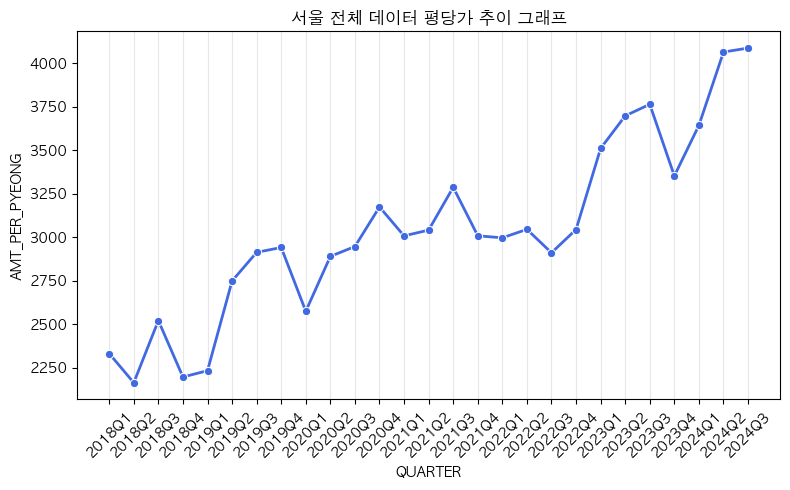

In [64]:
# 서울 전체 데이터 평당가 추이 그래프 시각화
ppp_seoul = df.groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=ppp_seoul, x='QUARTER', y='AMT_PER_PYEONG',
             marker='o', linewidth=2, color='royalblue')
plt.title("서울 전체 데이터 평당가 추이 그래프")
plt.xticks(rotation=45)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout() 
plt.show()

In [ ]:
import matplotlib.gridspec as gridspec

def plot_gu_master_analysis_v2(dfm, gu_name):
    # 0. 서울 전체 평균 미리 계산 (기준선용)
    seoul_avg = dfm.groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
    
    # 1. 자치구 데이터 필터링
    gu_dfm = dfm[dfm['CGG_NM'] == gu_name].copy()
    if gu_dfm.empty:
        print(f"'{gu_name}' 데이터가 없습니다.")
        return

    fig = plt.figure(figsize=(16, 18))
    gs = gridspec.GridSpec(3, 2, figure=fig)
    
    # --- 상단: [자치구 vs 서울 전체] 비교 ---
    ax_top = fig.add_subplot(gs[0, :])
    
    # [A] 서울 전체 평균 (기준선)
    sns.lineplot(data=seoul_avg, x='QUARTER', y='AMT_PER_PYEONG', 
                 ax=ax_top, color='gray', linestyle='--', linewidth=2, label='서울 전체 평균')
    
    # [B] 자치구 전체 평균 (강조선)
    total_data = gu_dfm.groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
    sns.lineplot(data=total_data, x='QUARTER', y='AMT_PER_PYEONG', marker='o', 
                 ax=ax_top, color='black', linewidth=3, label=f'{gu_name} 전체 평균')
    
    for _, label in enumerate(total_data['QUARTER']):
        if label.endswith('Q4'):
            ax_top.axvline(x=label, color='hotpink', linestyle='--', alpha=0.3)

    ax_top.set_title(f"[{gu_name}] vs 서울 전체 평당가 추이 비교", fontsize=16, fontweight='bold')
    ax_top.set_ylabel("평균 평당가")
    ax_top.legend() # 범례 표시
    ax_top.tick_params(axis='x', rotation=45)
    ax_top.grid(True, alpha=0.3)

    # --- 하단: 용도별 4개 그래프 (이전과 동일) ---
    usg_types = ['단독다가구', '아파트', '연립다세대', '오피스텔']
    colors = ['royalblue', 'darkorange', 'forestgreen', 'crimson']
    positions = [(1, 0), (1, 1), (2, 0), (2, 1)]

    for i, usg in enumerate(usg_types):
        ax = fig.add_subplot(gs[positions[i]])
        data = gu_dfm[gu_dfm['BLDG_USG'] == usg].groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
        seoul_data = dfm[dfm['BLDG_USG'] == usg].groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
        
        if not data.empty:
            sns.lineplot(data=data, x='QUARTER', y='AMT_PER_PYEONG', marker='o', 
                         ax=ax, color=colors[i], linewidth=2)
            sns.lineplot(data=seoul_data, x='QUARTER', y='AMT_PER_PYEONG', 
                        ax=ax, color='gray', linestyle='--', linewidth=2, label='서울 전체 평균')
            for _, label in enumerate(data['QUARTER']):
                if label.endswith('Q4'):
                    ax.axvline(x=label, color='hotpink', linestyle='--', alpha=0.3)
        
        ax.set_title(f"{usg} 추이", fontsize=13)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.2)

    plt.suptitle(f"{gu_name} 부동산 시장 심층 분석 (Standard: 서울 전체)", fontsize=22, y=1.02)
    plt.tight_layout()
    plt.show()

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777307 entries, 0 to 777306
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0.1    777307 non-null  int64  
 1   Unnamed: 0      777307 non-null  int64  
 2   CGG_CD          777307 non-null  int64  
 3   CGG_NM          777307 non-null  object 
 4   STDG_CD         777307 non-null  int64  
 5   STDG_NM         777307 non-null  object 
 6   BLDG_NM         724951 non-null  object 
 7   CTRT_DAY        777307 non-null  object 
 8   THING_AMT       777307 non-null  int64  
 9   ARCH_AREA       777307 non-null  float64
 10  LAND_AREA       617714 non-null  float64
 11  FLR             725003 non-null  float64
 12  RGHT_SE         2374 non-null    object 
 13  ARCH_YR         777307 non-null  int64  
 14  BLDG_USG        777307 non-null  object 
 15  DCLR_SE         206848 non-null  object 
 16  CTRT_YEAR       777307 non-null  int64  
 17  QUARTER   

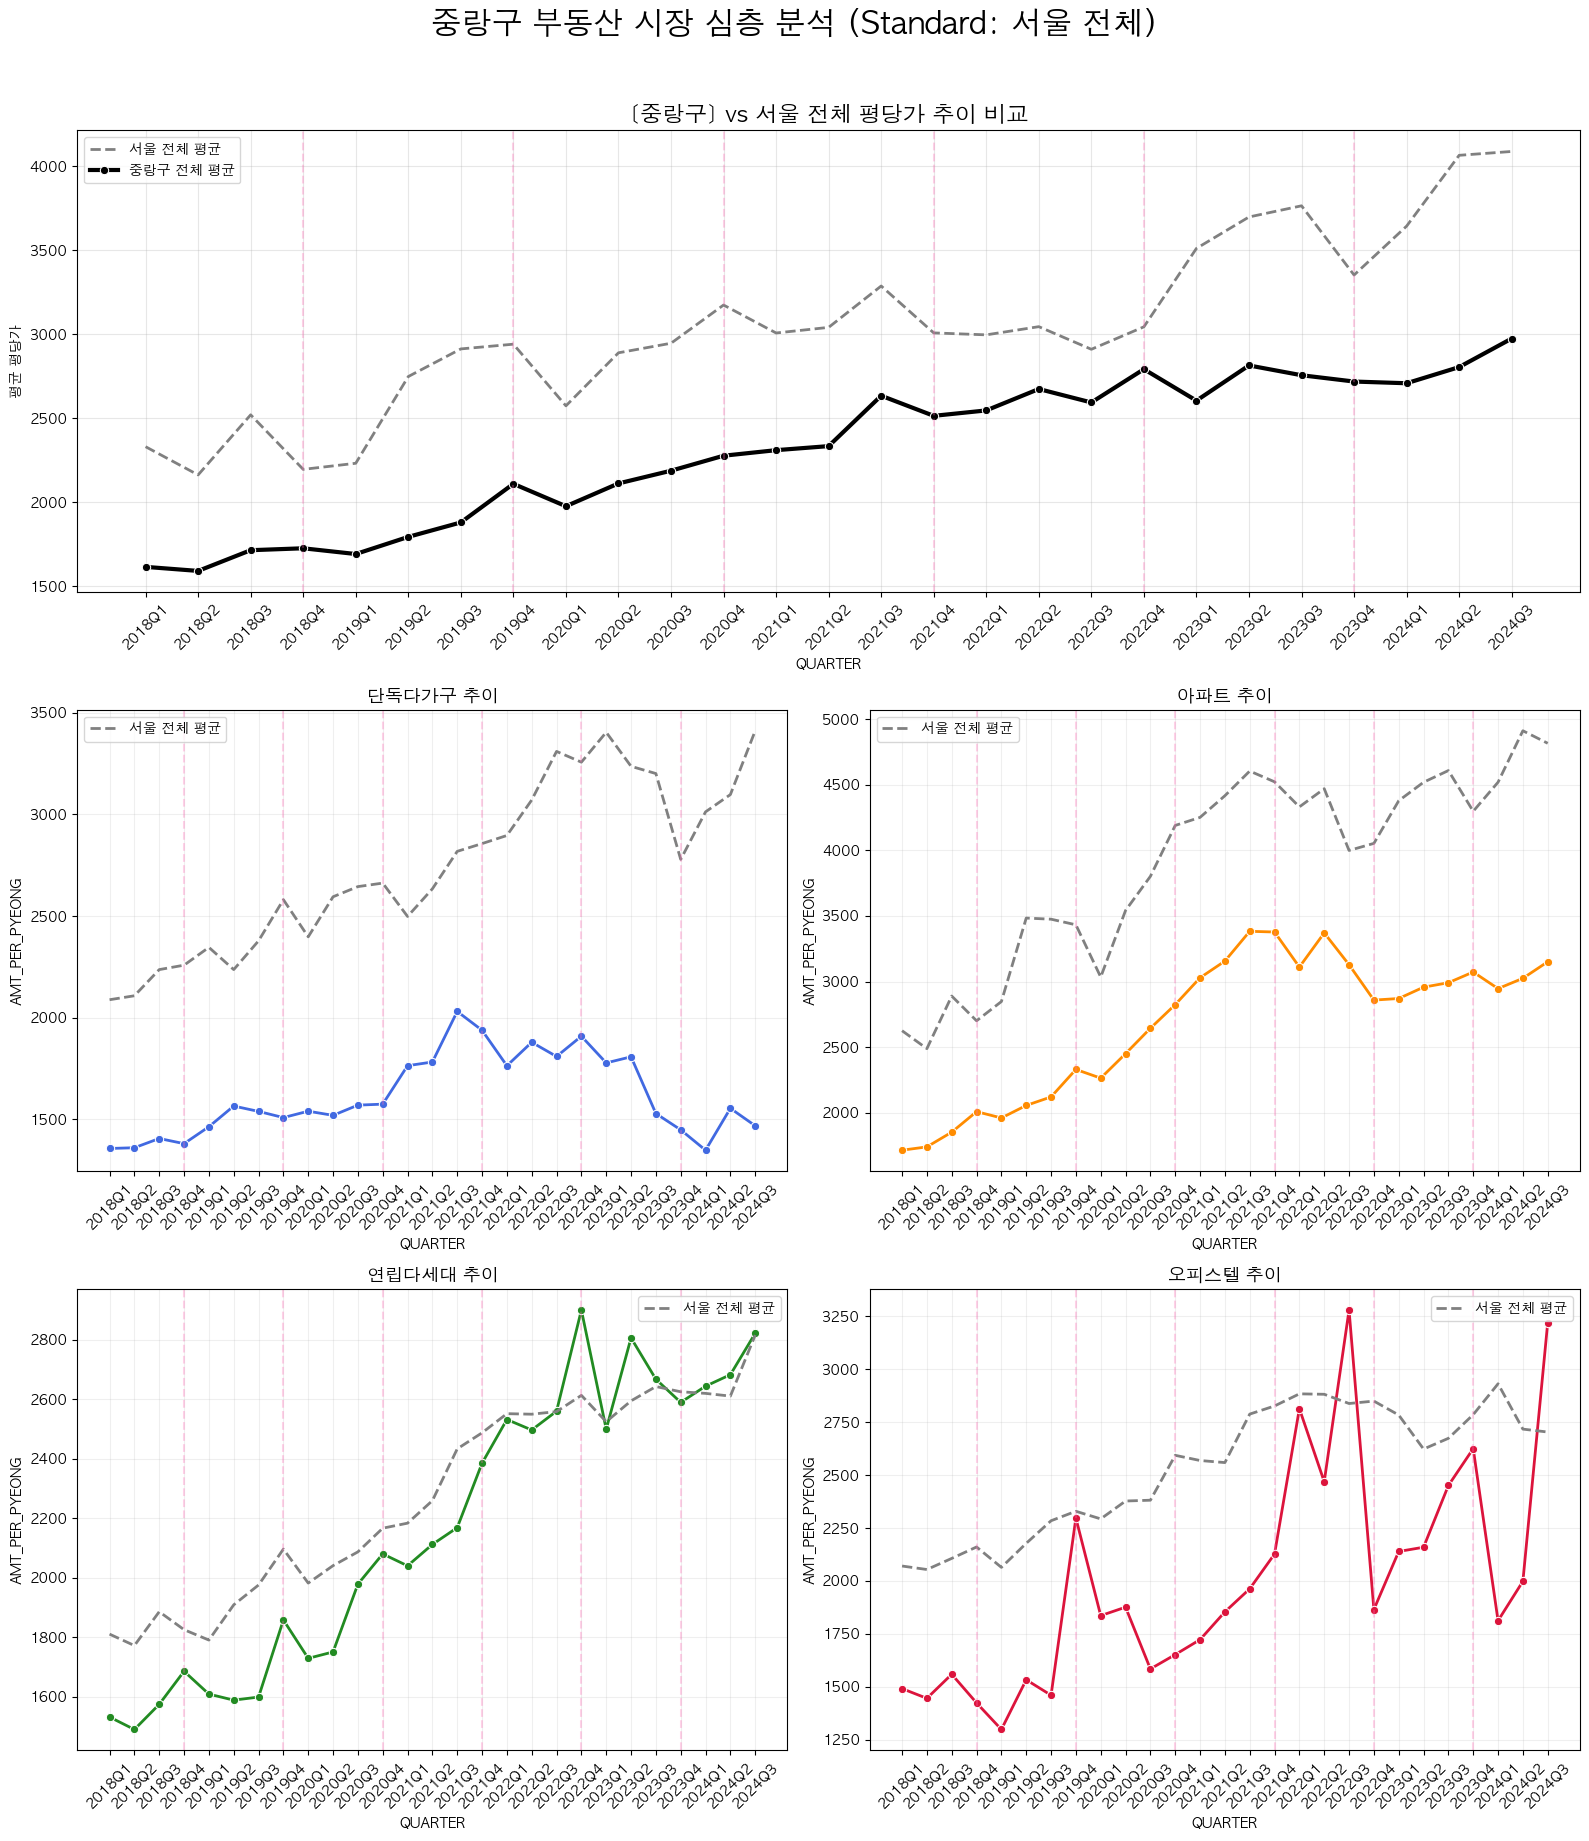

In [67]:
# 실행
plot_gu_master_analysis_v2(df, '중랑구')

In [ ]:
import pandas as pd

def analyze_jn_officetel_neighborhoods(df):
    # 1. 중랑구 오피스텔 및 연도 범위 필터링 (2017~2024)
    mask = (
        (df['CGG_NM'] == '중랑구') & 
        (df['BLDG_USG'] == '오피스텔')
    )
    df_jn = df.loc[mask].copy()

    # 연도별로 결과를 저장할 리스트
    yearly_summary = []

    # 2. 연도별 루프 수행
    years = sorted(df_jn['CTRT_YEAR'].unique())
    
    for year in years:
        year_data = df_jn[df_jn['CTRT_YEAR'] == year]
        total_count = len(year_data)
        
        if total_count == 0:
            continue
            
        # 법정동별 거래 건수 및 비중 계산
        counts = year_data['STDG_NM'].value_counts()
        ratios = (counts / total_count * 100).round(1)
        
        # 데이터프레임으로 병합
        temp_df = pd.DataFrame({
            '연도': year,
            '법정동': counts.index,
            '거래건수': counts.values,
            '비중(%)': ratios.values
        })
        
        # 3. 상위 3순위 추출
        top3 = temp_df.head(3).copy()
        top3['순위'] = [1, 2, 3]
        
        yearly_summary.append(top3)

    # 4. 결과 통합 및 출력
    final_result = pd.concat(yearly_summary).reset_index(drop=True)
    
    # 보기 편하게 컬럼 순서 재배치
    final_result = final_result[['연도', '순위', '법정동', '거래건수', '비중(%)']]
    
    return final_result

# 함수 실행
jn_neighborhood_top3 = analyze_jn_officetel_neighborhoods(df)

# 결과 출력
print("--- 중랑구 오피스텔 연도별 법정동 TOP 3 비중 ---")
display(jn_neighborhood_top3) # 주피터 노트북 환경일 경우 display 사용

--- 중랑구 오피스텔 연도별 법정동 TOP 3 비중 ---


,연도,순위,법정동,거래건수,비중(%)
0,2018,1,상봉동,34,37.4
1,2018,2,신내동,23,25.3
2,2018,3,망우동,15,16.5
3,2019,1,상봉동,48,41.0
4,2019,2,면목동,32,27.4
5,2019,3,신내동,20,17.1
6,2020,1,상봉동,67,43.2
7,2020,2,신내동,35,22.6
8,2020,3,망우동,28,18.1
9,2021,1,면목동,52,25.4


In [72]:
jungrang = df[(df['BLDG_USG']=='오피스텔') & (df['STDG_NM']=='상봉동') & (df['CTRT_YEAR']==2019)]
jungrang

,Unnamed: 0.1,Unnamed: 0,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,...,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,QUARTER,QUARTER_INT,CTRT_BLDG_AGE,AMT_PER_AREA,AMT_PER_PYEONG
703593,703593,169741,11260,중랑구,10200,상봉동,라메즈오피스텔(104-32),2019-12-13,13000,26.60,...,NaN,2004,오피스텔,NaN,2019,2019Q4,12,15,488.721805,1615.616541
703973,703973,174880,11260,중랑구,10200,상봉동,동일씨엘로,2019-11-28,14917,17.05,...,NaN,2019,오피스텔,NaN,2019,2019Q4,11,0,874.897361,2892.235695
704117,704117,176986,11260,중랑구,10200,상봉동,동일씨엘로,2019-11-23,14707,17.05,...,NaN,2019,오피스텔,NaN,2019,2019Q4,11,0,862.580645,2851.519097
704205,704205,178381,11260,중랑구,10200,상봉동,시네마시티,2019-11-20,12000,38.88,...,NaN,2000,오피스텔,NaN,2019,2019Q4,11,19,308.641975,1020.308642
704279,704279,179254,11260,중랑구,10200,상봉동,한일써너스빌,2019-11-18,17000,42.04,...,NaN,2003,오피스텔,NaN,2019,2019Q4,11,16,404.376784,1336.788773
704581,704581,184255,11260,중랑구,10200,상봉동,예지다움,2019-11-08,21300,29.93,...,NaN,2018,오피스텔,NaN,2019,2019Q4,11,1,711.660541,2352.607417
704908,704908,189754,11260,중랑구,10200,상봉동,라메즈오피스텔(104-32),2019-10-30,9000,26.60,...,NaN,2004,오피스텔,NaN,2019,2019Q4,10,15,338.345865,1118.503759
704927,704927,189988,11260,중랑구,10200,상봉동,예지다움,2019-10-29,20000,29.84,...,NaN,2018,오피스텔,NaN,2019,2019Q4,10,1,670.241287,2215.683646
705003,705003,191141,11260,중랑구,10200,상봉동,더클래스,2019-10-27,23770,41.83,...,NaN,2019,오피스텔,NaN,2019,2019Q4,10,0,568.252450,1878.528951
705657,705657,195821,11260,중랑구,10200,상봉동,이안채 S타워 B,2019-10-20,10073,15.30,...,NaN,2019,오피스텔,NaN,2019,2019Q4,10,0,658.366013,2176.426366


--- 금천구 오피스텔 분기별 거래량 추이 ---
   QUARTER  거래건수
0   2018Q1    20
1   2018Q2    19
2   2018Q3    35
3   2018Q4    29
4   2019Q1    40
5   2019Q2    31
6   2019Q3   266
7   2019Q4    61
8   2020Q1   247
9   2020Q2   236
10  2020Q3   151
11  2020Q4   155
12  2021Q1   314
13  2021Q2   290
14  2021Q3   112
15  2021Q4   136
16  2022Q1   282
17  2022Q2   718
18  2022Q3   139
19  2022Q4    60
20  2023Q1   342
21  2023Q2    50
22  2023Q3   102
23  2023Q4   144
24  2024Q1   468
25  2024Q2   101
26  2024Q3    92


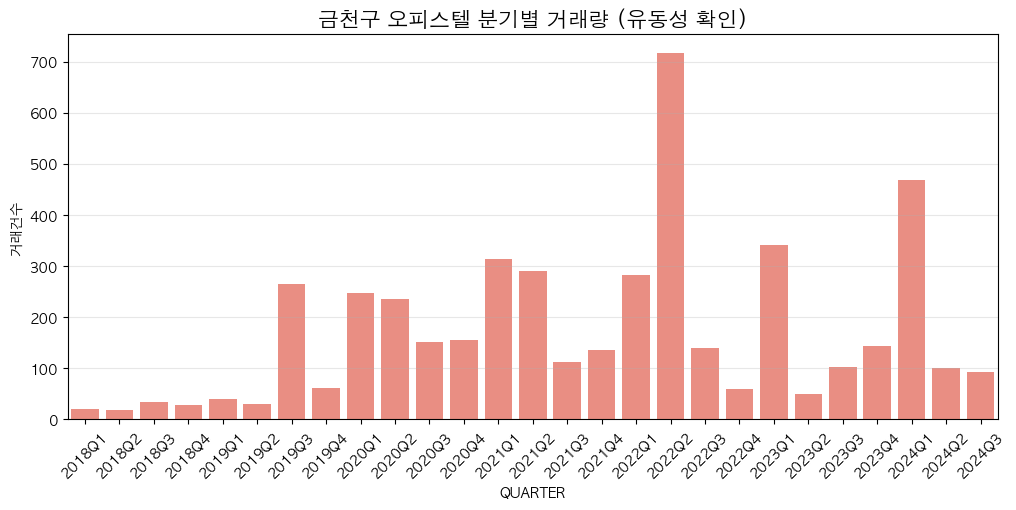

In [73]:
# 1. 금천구 오피스텔 데이터만 필터링
jn_off_data = df[(df['CGG_NM'] == '금천구') & (df['BLDG_USG'] == '오피스텔')].copy()

# 2. 분기별 거래량 집계 (bungi 또는 QUARTER 컬럼 사용)
jn_off_vol = jn_off_data.groupby('QUARTER').size().reset_index(name='거래건수')

# 3. 데이터 확인
print("--- 금천구 오피스텔 분기별 거래량 추이 ---")
print(jn_off_vol.sort_values('QUARTER'))

# (옵션) 시각화로 즉시 확인
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sns.barplot(data=jn_off_vol, x='QUARTER', y='거래건수', color='salmon')
plt.title("금천구 오피스텔 분기별 거래량 (유동성 확인)", fontsize=15)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [74]:
df2=df.copy()

In [75]:
""" 
# 건물용도별 분기별 평균 평당가 데이터
mean_AMT_PER_PYEONG_quarter = df.groupby(['BLDG_USG','QUARTER'], as_index=False)['AMT_PER_PYEONG'].mean() 
mean_AMT_PER_PYEONG_quarter

# 건물용도별로 나누어 분기별 건물가격 확인
dan2 = mean_AMT_PER_PYEONG_quarter[mean_AMT_PER_PYEONG_quarter['BLDG_USG']=='단독다가구'].copy()
apt2 = mean_AMT_PER_PYEONG_quarter[mean_AMT_PER_PYEONG_quarter['BLDG_USG']=='아파트'].copy()
yeon2 = mean_AMT_PER_PYEONG_quarter[mean_AMT_PER_PYEONG_quarter['BLDG_USG']=='연립다세대'].copy()
off2 = mean_AMT_PER_PYEONG_quarter[mean_AMT_PER_PYEONG_quarter['BLDG_USG']=='오피스텔'].copy()

# 건물용도별 분기별 평당가의 증감폭
dan2['diff'] = dan2['AMT_PER_PYEONG'].diff().fillna(0)
apt2['diff'] = apt2['AMT_PER_PYEONG'].diff().fillna(0)
yeon2['diff'] = yeon2['AMT_PER_PYEONG'].diff().fillna(0)
off2['diff'] = off2['AMT_PER_PYEONG'].diff().fillna(0)
"""

" \n# 건물용도별 분기별 평균 평당가 데이터\nmean_AMT_PER_PYEONG_quarter = df.groupby(['BLDG_USG','QUARTER'], as_index=False)['AMT_PER_PYEONG'].mean() \nmean_AMT_PER_PYEONG_quarter\n\n# 건물용도별로 나누어 분기별 건물가격 확인\ndan2 = mean_AMT_PER_PYEONG_quarter[mean_AMT_PER_PYEONG_quarter['BLDG_USG']=='단독다가구'].copy()\napt2 = mean_AMT_PER_PYEONG_quarter[mean_AMT_PER_PYEONG_quarter['BLDG_USG']=='아파트'].copy()\nyeon2 = mean_AMT_PER_PYEONG_quarter[mean_AMT_PER_PYEONG_quarter['BLDG_USG']=='연립다세대'].copy()\noff2 = mean_AMT_PER_PYEONG_quarter[mean_AMT_PER_PYEONG_quarter['BLDG_USG']=='오피스텔'].copy()\n\n# 건물용도별 분기별 평당가의 증감폭\ndan2['diff'] = dan2['AMT_PER_PYEONG'].diff().fillna(0)\napt2['diff'] = apt2['AMT_PER_PYEONG'].diff().fillna(0)\nyeon2['diff'] = yeon2['AMT_PER_PYEONG'].diff().fillna(0)\noff2['diff'] = off2['AMT_PER_PYEONG'].diff().fillna(0)\n"

In [76]:
import matplotlib.gridspec as gridspec

def plot_gu_master_analysis_diff_only(dfm, gu_name):

    # 서울시 변동률이 큰 분기만 따로 강조
    special_quarters = ['2018Q3', '2018Q4', '2019Q2', '2020Q1', '2023Q1', '2023Q4']
    # 0. 서울 전체 데이터의 분기별 평당가 증감폭(diff) 계산
    seoul_total = dfm.groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
    seoul_total['diff'] = seoul_total['AMT_PER_PYEONG'].diff().fillna(0)
    
    # 1. 자치구 데이터 필터링 및 증감폭 계산
    gu_dfm = dfm[dfm['CGG_NM'] == gu_name].copy()
    if gu_dfm.empty:
        print(f"'{gu_name}' 데이터가 없습니다.")
        return
    
    gu_total = gu_dfm.groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
    gu_total['diff'] = gu_total['AMT_PER_PYEONG'].diff().fillna(0)

    fig = plt.figure(figsize=(16, 18))
    gs = gridspec.GridSpec(3, 2, figure=fig)
    
    # --- 상단: [자치구 전체 vs 서울 전체] 증감폭 비교 ---
    ax_top = fig.add_subplot(gs[0, :])
    
    # 서울 전체 증감폭 (기준선)
    sns.lineplot(data=seoul_total, x='QUARTER', y='diff', 
                 ax=ax_top, color='silver', linestyle='--', linewidth=2, label='서울 전체 증감폭')
    
    # 자치구 전체 증감폭 (강조선)
    sns.lineplot(data=gu_total, x='QUARTER', y='diff', marker='o', 
                 ax=ax_top, color='black', linewidth=3, label=f'{gu_name} 증감폭')
    
    # 특정 분기 빨간 네모 포인트 찍기 (상단 그래프)
    highlight_data = gu_total[gu_total['QUARTER'].isin(special_quarters)]
    ax_top.scatter(highlight_data['QUARTER'], highlight_data['diff'], 
                   color='red', marker='s', s=120, zorder=5, label='특이 분기')
    
    # 0선(기준선) 추가 - 상승과 하락을 명확히 구분
    ax_top.axhline(0, color='red', linestyle='-', alpha=0.2)
    
    for idx, label in enumerate(gu_total['QUARTER']):
        if label.endswith('Q4'):
            ax_top.axvline(x=label, color='hotpink', linestyle='--', alpha=0.5)

    ax_top.set_title(f"[{gu_name}] vs 서울 전체 평당가 증감폭(diff) 추이 비교", fontsize=16, fontweight='bold')
    ax_top.set_ylabel("평당가 증감액 (전분기 대비)")
    ax_top.legend()
    ax_top.tick_params(axis='x', rotation=45)
    ax_top.grid(True, alpha=0.3)

    # --- 하단: 용도별 4개 그래프 증감폭 비교 ---
    usg_types = ['단독다가구', '아파트', '연립다세대', '오피스텔']
    colors = ['royalblue', 'darkorange', 'forestgreen', 'crimson']
    positions = [(1, 0), (1, 1), (2, 0), (2, 1)]

    for i, usg in enumerate(usg_types):
        ax = fig.add_subplot(gs[positions[i]])
        
        # 자치구 용도별 diff
        gu_data = gu_dfm[gu_dfm['BLDG_USG'] == usg].groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
        gu_data['diff'] = gu_data['AMT_PER_PYEONG'].diff().fillna(0)
        
        # 서울 전체 용도별 diff (비교용)
        seoul_data = dfm[dfm['BLDG_USG'] == usg].groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
        seoul_data['diff'] = seoul_data['AMT_PER_PYEONG'].diff().fillna(0)
        
        if not gu_data.empty:
            # 서울 용도별 평균 (배경)
            sns.lineplot(data=seoul_data, x='QUARTER', y='diff', 
                        ax=ax, color='silver', linestyle='--')
            # 자치구 용도별 (강조)
            sns.lineplot(data=gu_data, x='QUARTER', y='diff', marker='o', 
                         ax=ax, color=colors[i], linewidth=2, label=f'{gu_name} {usg}')
            # 특정 분기 빨간 네모 포인트 찍기 (하단 개별 그래프)
            gu_highlight = gu_data[gu_data['QUARTER'].isin(special_quarters)]
            ax.scatter(gu_highlight['QUARTER'], gu_highlight['diff'], 
                       color='red', marker='s', s=100, zorder=5)
            
            ax.axhline(0, color='red', linestyle='-', alpha=0.1)
            for idx, label in enumerate(gu_data['QUARTER']):
                if label.endswith('Q4'):
                    ax.axvline(x=label, color='hotpink', linestyle='--', alpha=0.3)
        
        ax.set_title(f"{usg} 증감폭 추이", fontsize=13)
        ax.set_ylabel("증감액")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.2)

    plt.suptitle(f"{gu_name} 부동산 시장 변동성 분석 (Price Delta)", fontsize=22, y=1.02)
    plt.tight_layout()
    plt.show()

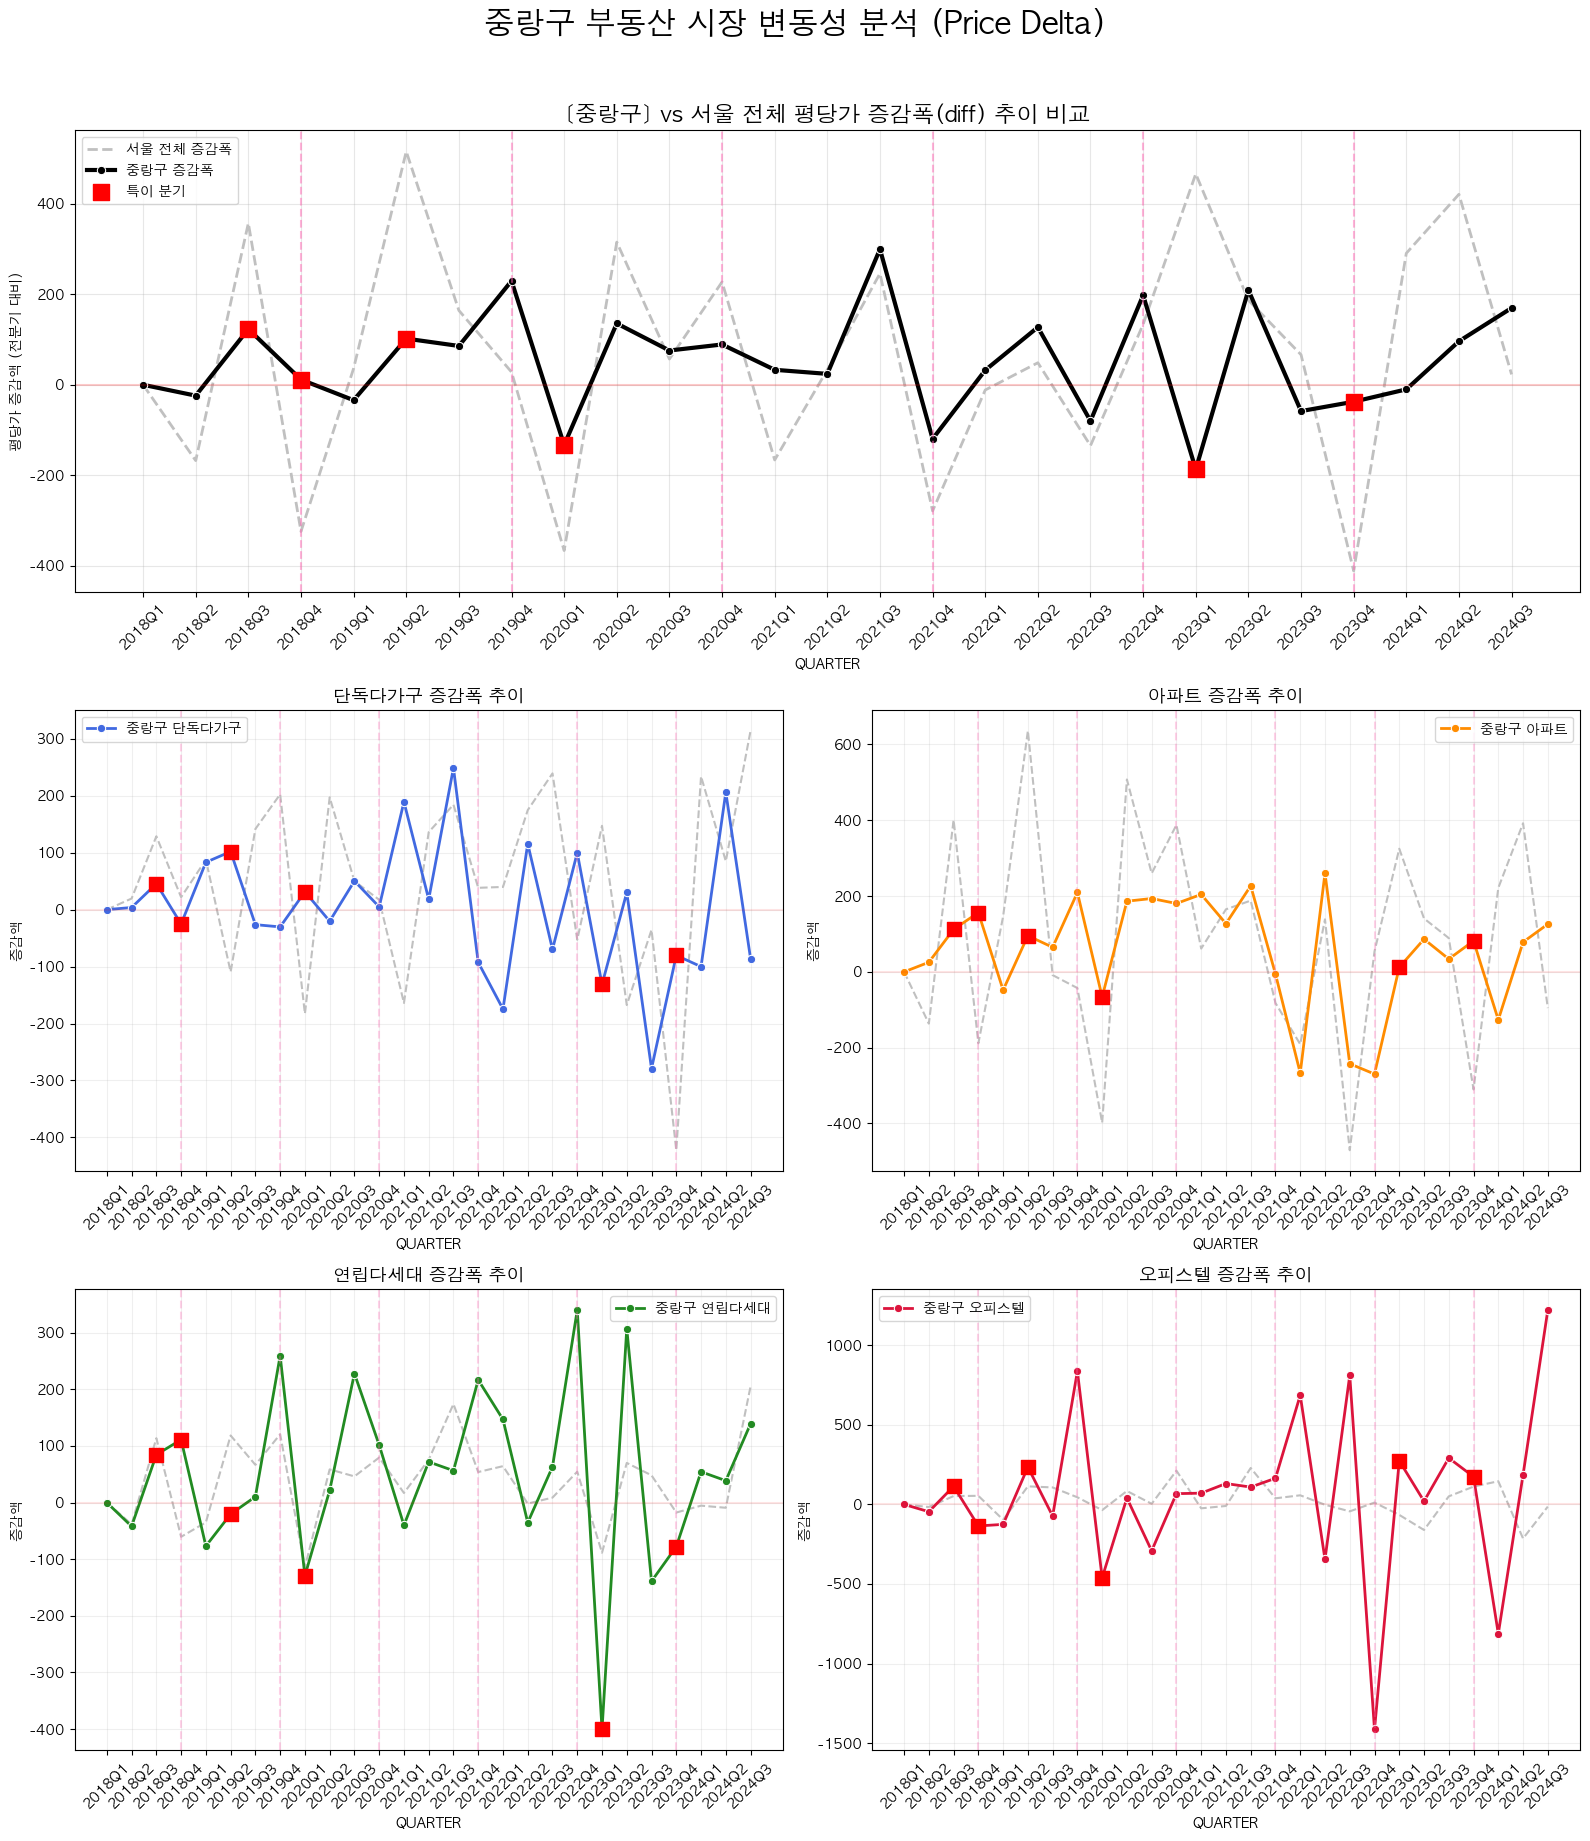

In [77]:
plot_gu_master_analysis_diff_only(df, '중랑구')

## 중랑구 오피스텔

이제 다른거 다 필요없고 두가지 페르소나로 나눠서 그래프를 만들거야. 하나는 중랑구의 오피스텔이야. 이게 2018년 1분기부터 2024년 3분기까지 ROI를 보는데 실제로 매물 가격은 높지 않았지만 ROI 값이 크기 때문에 이 매물을 사는게 되게 합리적이고 이익 측면에서 유리한 전략이라고 할 수 있잖아. 그래서 이 중랑구 오피스텔의 평당가 추이를 서울 전체의 평당가 추이와 비교하면 좋겠고, 증감률 자체도 비교를 했으면 좋겠어. 증감폭도 비교를 해보고 싶고. 그래서 10억원이 있었을 때 어느정도의 수익률을 얻을 수 있는지 알겠는데 그러면 여기서 10억원 한정에서 어느 시점에 샀으면 얼마까지 벌 수 있었을거고 어떤 이유로 증가를 했는지도 알고싶고 그럼 어떤 판단을 내려서 가격이 낮은 매물일지라도 크게 증가할거라는 판단을 할 수 있을지에 대한 인사이트도 필요해

성공 이유: 1. 동부간선도로 지하화 & 중랑구 재개발: 열악했던 교통 환경 개선 기대감 반영. 2. 풍선 효과: 강남/마용성 가격이 급등하자 상대적으로 저렴한 외곽 지역으로 투자 수요 이동. 3. 1인 가구 증가: 상봉역, 망우역 인근 역세권 오피스텔 수요 급증.

② 인프라의 '상전벽해' (Infrastructure Shift)
단순한 공원 조성이 아니라, **'일자리'나 '교통망'**이 통째로 바뀌는 지를 봐야 합니다.
- GTX 노선 확정, 지하철 연장, 대규모 복합역사 개발 등이 예정된 저평가 지역이 ROI가 가장 높습니다.

③ 용도별 희소성 (Supply & Demand)
중랑구에 아파트는 많아도 신축 오피스텔 공급이 부족하다면? 수요는 넘치는데 공급이 귀해지는 시점에 가격은 폭발합니다.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

def plot_gu_comparison_master(dfm, gu_name):
    # 1. 데이터 필터링 및 전처리 (기존과 동일)
    gu_off = dfm[(dfm['CGG_NM'] == gu_name) & (dfm['BLDG_USG'] == '오피스텔')].copy()
    if gu_off.empty:
        print(f"'{gu_name}'의 오피스텔 데이터가 없습니다.")
        return

    seoul_off = dfm[dfm['BLDG_USG'] == '오피스텔'].copy() # 서울 오피스텔
    seoul_all = dfm.copy() # 서울 건물 전체 용도

    def get_pct_chg(target_df):
        stats = target_df.groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index() # 분기별 평당가 평균 데이터프레임
        stats['pct_chg'] = stats['AMT_PER_PYEONG'].pct_change().fillna(0) * 100 # 전 분기와 비교했을 때의 증감률 (변동률)
        return stats

    # 해당 자치구 분기별 평당가 평균과 분기별 빈도수
    gu_off_stats = gu_off.groupby('QUARTER')['AMT_PER_PYEONG'].agg(['mean', 'size']).reset_index()
    # 전 분기와 비교했을 때의 증감률 (변동률)
    gu_off_stats['pct_chg'] = gu_off_stats['mean'].pct_change().fillna(0) * 100
    
    s_off_stats = get_pct_chg(seoul_off)
    s_all_stats = get_pct_chg(seoul_all)

    # 2. 시각화 (이중 축 설정)
    _, ax1 = plt.subplots(figsize=(18, 9))

    # [왼쪽 Y축] 막대그래프 (label 제거하여 자동 범례 생성 방지)
    bar_color = 'skyblue'
    sns.barplot(data=gu_off_stats, x='QUARTER', y='size', ax=ax1, color=bar_color, alpha=0.4)
    ax1.set_ylabel('자치구 오피스텔 거래 건수', fontsize=12, fontweight='bold')
    ax1.set_xlabel('분기', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)

    # [오른쪽 Y축] 3가지 변동률
    ax2 = ax1.twinx()
    
    # 각 lineplot에서 label 제거하여 자동 범례 생성 방지
    # 전체 서울 건물 용도 전체 분기별 전분기 대비 평당가 변동률
    sns.lineplot(data=s_all_stats, x='QUARTER', y='pct_chg', ax=ax2,
                 color='silver', linewidth=1.5, linestyle='--')
    # 전체 서울 오피스텔 분기별 전분기 대비 평당가 변동률
    sns.lineplot(data=s_off_stats, x='QUARTER', y='pct_chg', ax=ax2, 
                 color='orange', linewidth=2, alpha=0.7)
    
    # 해당 자치구 오피스텔 분기별 전분기 대비 평당가 변동률
    sns.lineplot(data=gu_off_stats, x='QUARTER', y='pct_chg', ax=ax2, 
                 color='darkred', linewidth=4, marker='o', markersize=8)
    
    ax2.set_ylabel('전분기 대비 평당가 변동률 (%)', fontsize=12, fontweight='bold')
    ax2.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3) # y=0 위치에 수평선

    # 3. 마무리 및 범례 수동 통합 (범례 중복 해결 핵심)
    plt.title(f"[{gu_name}] 오피스텔 유동성 및 시장 비교 분석 (3중 선비교)", fontsize=20, fontweight='bold', pad=25)
    
    # 수동으로 범례 항목 생성
    patch = mpatches.Patch(color=bar_color, alpha=0.4, label=f'{gu_name} 오피스텔 거래량')
    line1 = plt.Line2D([0], [0], color='silver', linewidth=1.5, linestyle='--', label='서울 전체(모든 용도) 변동률')
    line2 = plt.Line2D([0], [0], color='orange', linewidth=2, label='서울 전체(오피스텔) 변동률')
    line3 = plt.Line2D([0], [0], color='darkred', linewidth=4, marker='o', label=f'{gu_name} 오피스텔 변동률')

    # 하나의 축(ax1)에 모든 핸들을 모아서 출력
    ax1.legend(handles=[patch, line3, line2, line1], loc='upper left', frameon=True, fontsize=10)
    
    plt.grid(True, axis='y', alpha=0.2)
    plt.tight_layout()
    plt.show()

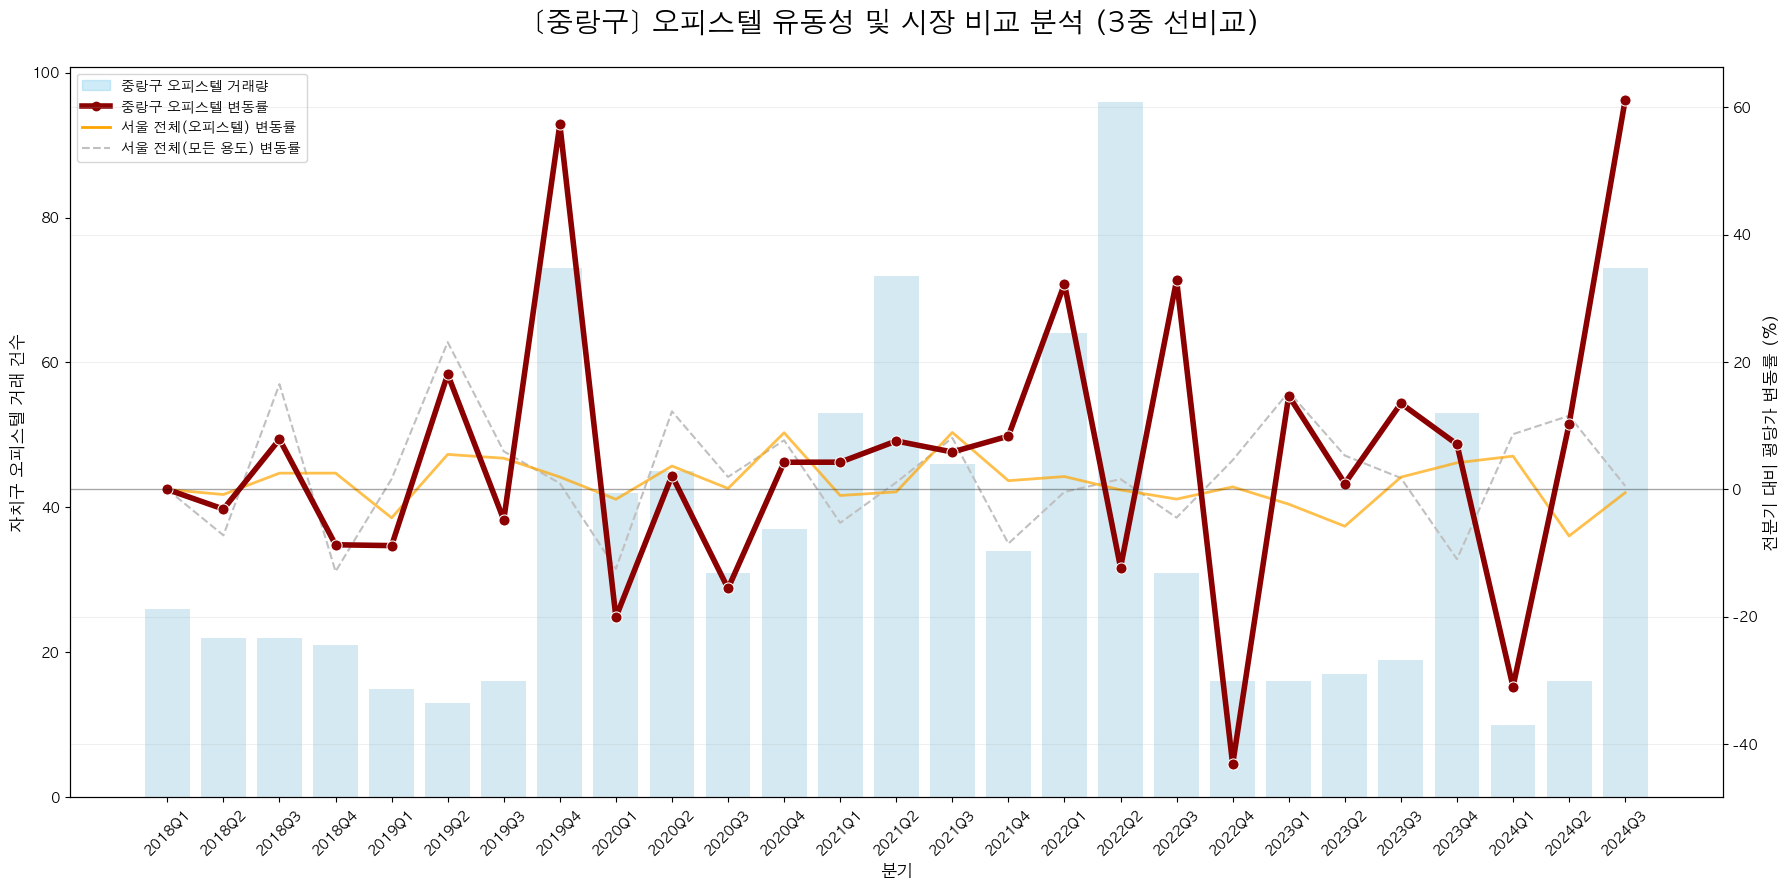

In [82]:
# 실행
plot_gu_comparison_master(df, "중랑구")

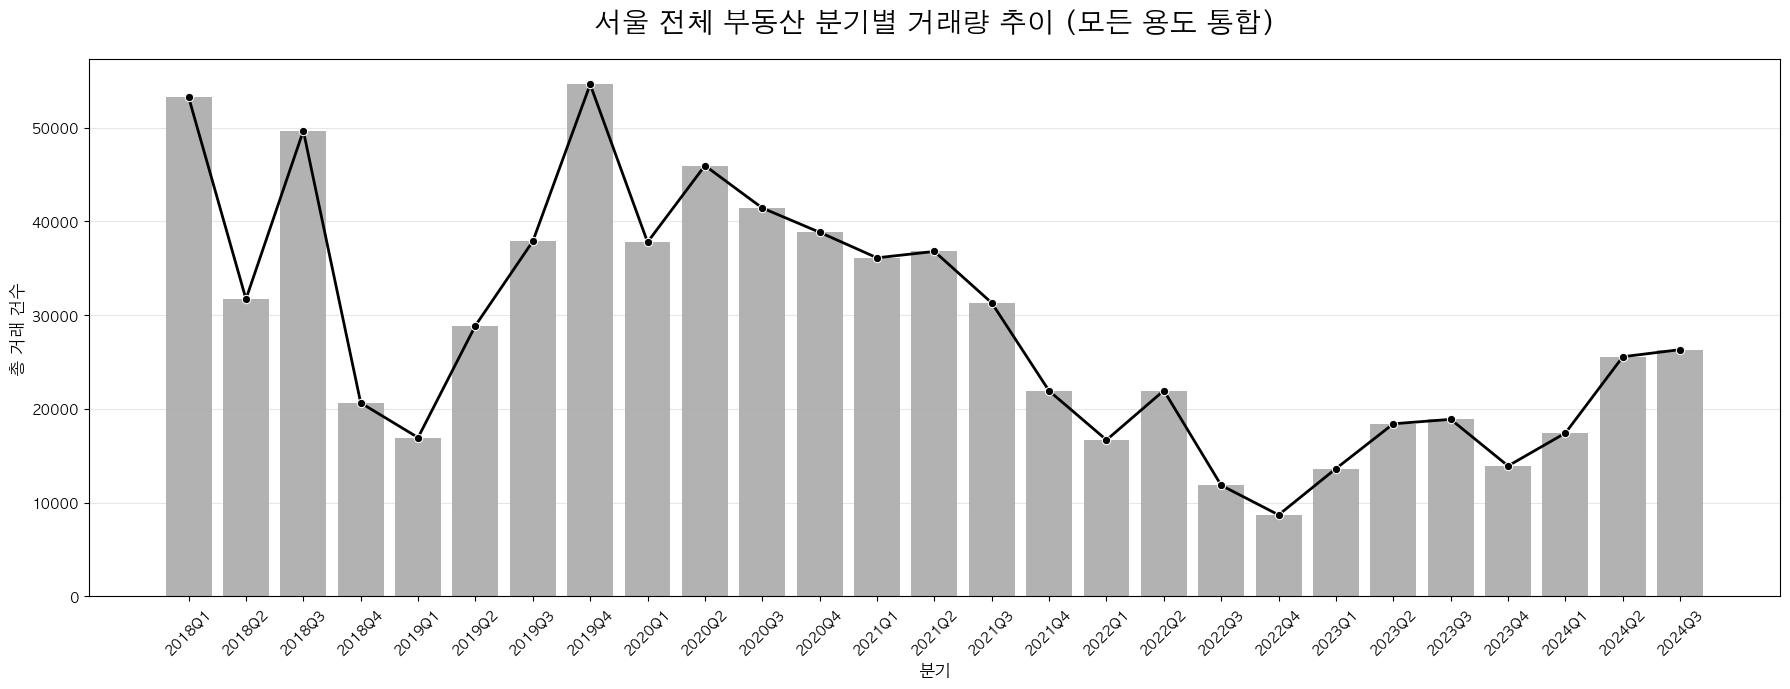

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_seoul_total_volume(dfm):
    # 1. 서울 전체 데이터의 분기별 거래량 집계
    seoul_vol = dfm.groupby('QUARTER').size().reset_index(name='count')
    
    # 2. 시각화
    plt.figure(figsize=(18, 7))
    
    # 거래량 막대 그래프
    sns.barplot(data=seoul_vol, x='QUARTER', y='count', color='gray', alpha=0.6)
    
    # 추세를 보기 위한 선 그래프 추가
    sns.lineplot(data=seoul_vol, x='QUARTER', y='count', color='black', marker='o', linewidth=2)

    # 3. 디자인 및 라벨링
    plt.title("서울 전체 부동산 분기별 거래량 추이 (모든 용도 통합)", fontsize=20, fontweight='bold', pad=20)
    plt.xlabel("분기", fontsize=12)
    plt.ylabel("총 거래 건수", fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# 실행
plot_seoul_total_volume(df)

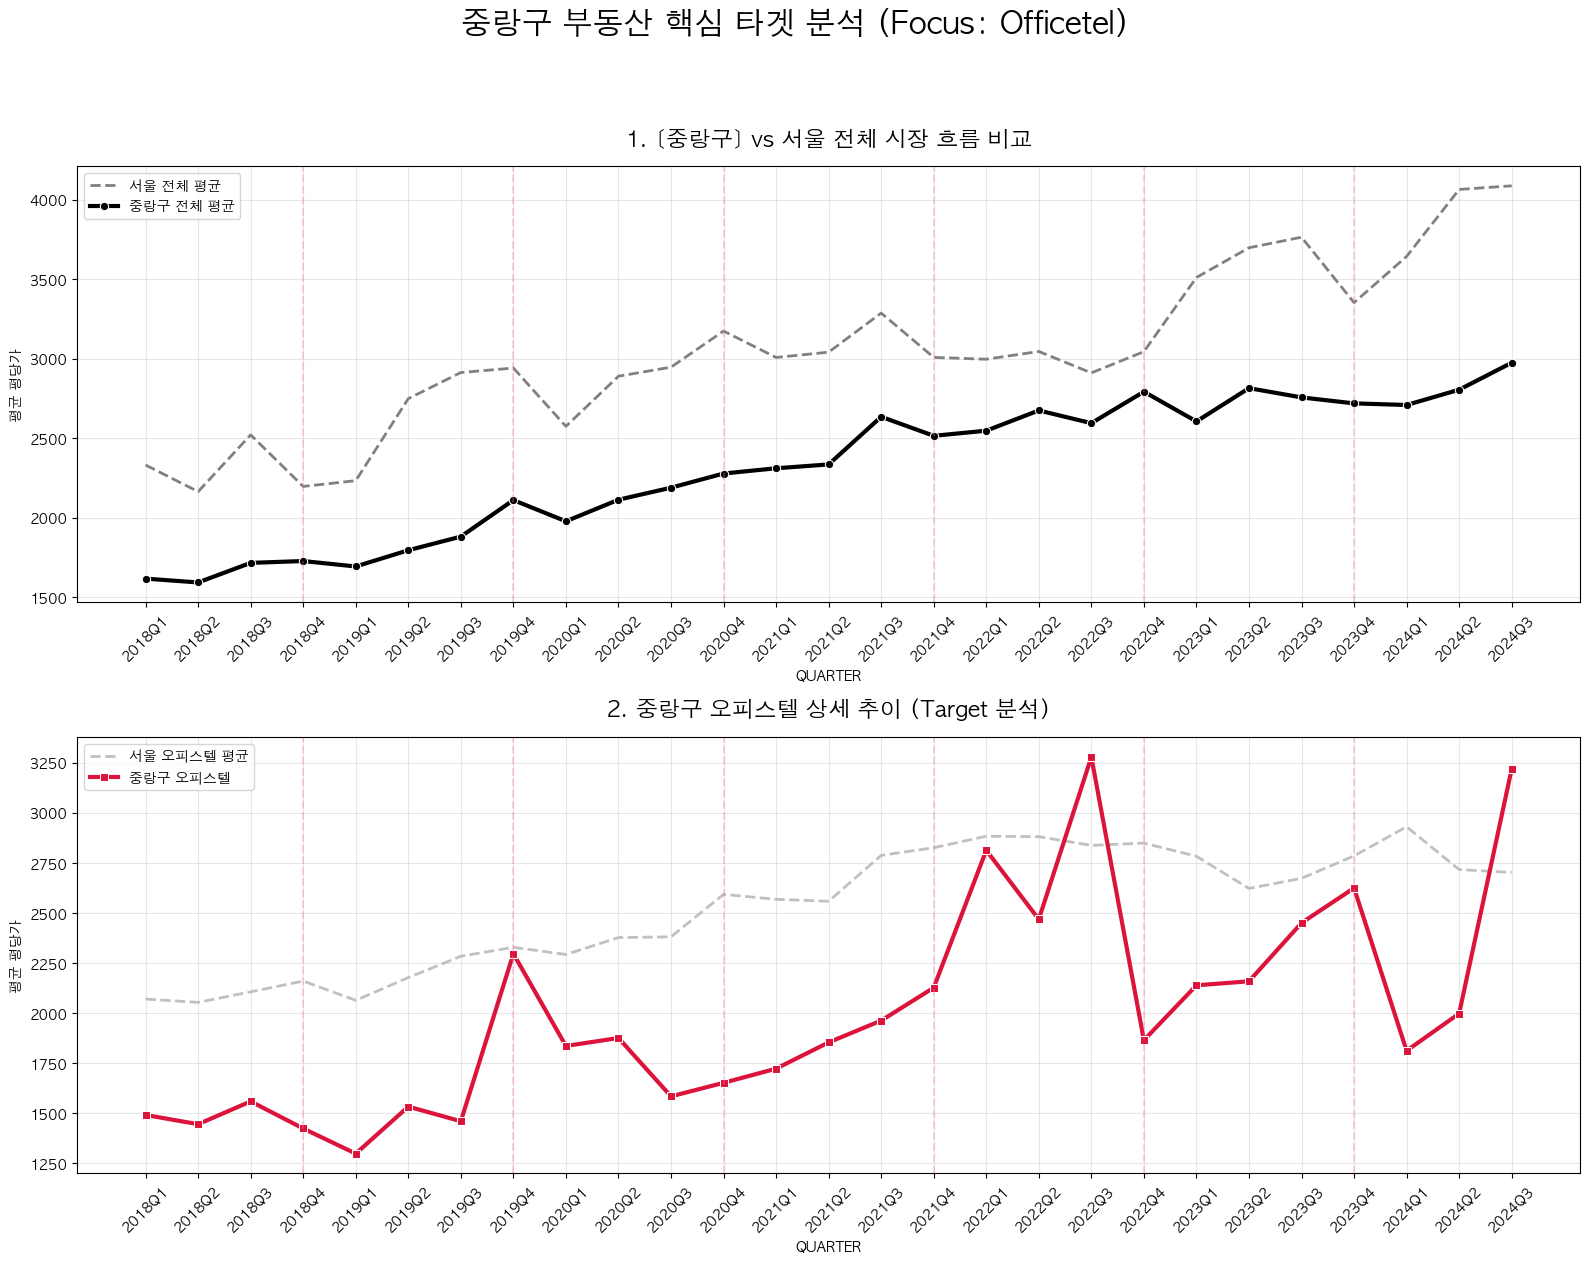

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

def plot_gu_focal_analysis(dfm, gu_name):
    # 0. 서울 전체 평균 미리 계산
    seoul_avg = dfm.groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
    
    # 1. 자치구 데이터 필터링
    gu_dfm = dfm[dfm['CGG_NM'] == gu_name].copy()
    if gu_dfm.empty:
        print(f"'{gu_name}' 데이터가 없습니다.")
        return

    # 2. 2단 구성으로 변경 (필요한 그래프 2개만 배치)
    fig = plt.figure(figsize=(16, 12))
    gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 1])
    
    # --- 상단: [자치구 vs 서울 전체] 비교 ---
    ax_top = fig.add_subplot(gs[0, :])
    
    # 서울 전체 평균 (기준선)
    sns.lineplot(data=seoul_avg, x='QUARTER', y='AMT_PER_PYEONG', 
                 ax=ax_top, color='gray', linestyle='--', linewidth=2, label='서울 전체 평균')
    
    # 자치구 전체 평균 (강조선)
    total_data = gu_dfm.groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
    sns.lineplot(data=total_data, x='QUARTER', y='AMT_PER_PYEONG', marker='o', 
                 ax=ax_top, color='black', linewidth=3, label=f'{gu_name} 전체 평균')
    
    # 연도 구분선 (Q4 기준)
    for label in total_data['QUARTER']:
        if label.endswith('Q4'):
            ax_top.axvline(x=label, color='hotpink', linestyle='--', alpha=0.3)

    ax_top.set_title(f"1. [{gu_name}] vs 서울 전체 시장 흐름 비교", fontsize=16, fontweight='bold', pad=15)
    ax_top.set_ylabel("평균 평당가")
    ax_top.legend(loc='upper left')
    ax_top.tick_params(axis='x', rotation=45)
    ax_top.grid(True, alpha=0.3)

    # --- 하단: 오피스텔 집중 분석 ---
    ax_bot = fig.add_subplot(gs[1, :])
    
    # 자치구 오피스텔 데이터
    off_data = gu_dfm[gu_dfm['BLDG_USG'] == '오피스텔'].groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
    # 서울 오피스텔 전체 데이터 (비교용)
    seoul_off = dfm[dfm['BLDG_USG'] == '오피스텔'].groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
    
    if not off_data.empty:
        # 서울 오피스텔 평균 (기준선)
        sns.lineplot(data=seoul_off, x='QUARTER', y='AMT_PER_PYEONG', 
                     ax=ax_bot, color='silver', linestyle='--', linewidth=2, label='서울 오피스텔 평균')
        # 자치구 오피스텔 (강조선)
        sns.lineplot(data=off_data, x='QUARTER', y='AMT_PER_PYEONG', marker='s', 
                     ax=ax_bot, color='crimson', linewidth=3, label=f'{gu_name} 오피스텔')
        
        for label in off_data['QUARTER']:
            if label.endswith('Q4'):
                ax_bot.axvline(x=label, color='hotpink', linestyle='--', alpha=0.3)
    
    ax_bot.set_title(f"2. {gu_name} 오피스텔 상세 추이 (Target 분석)", fontsize=16, fontweight='bold', pad=15)
    ax_bot.set_ylabel("평균 평당가")
    ax_bot.legend(loc='upper left')
    ax_bot.tick_params(axis='x', rotation=45)
    ax_bot.grid(True, alpha=0.3)

    plt.suptitle(f"{gu_name} 부동산 핵심 타겟 분석 (Focus: Officetel)", fontsize=22, y=1.05, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 실행
plot_gu_focal_analysis(df, "중랑구")

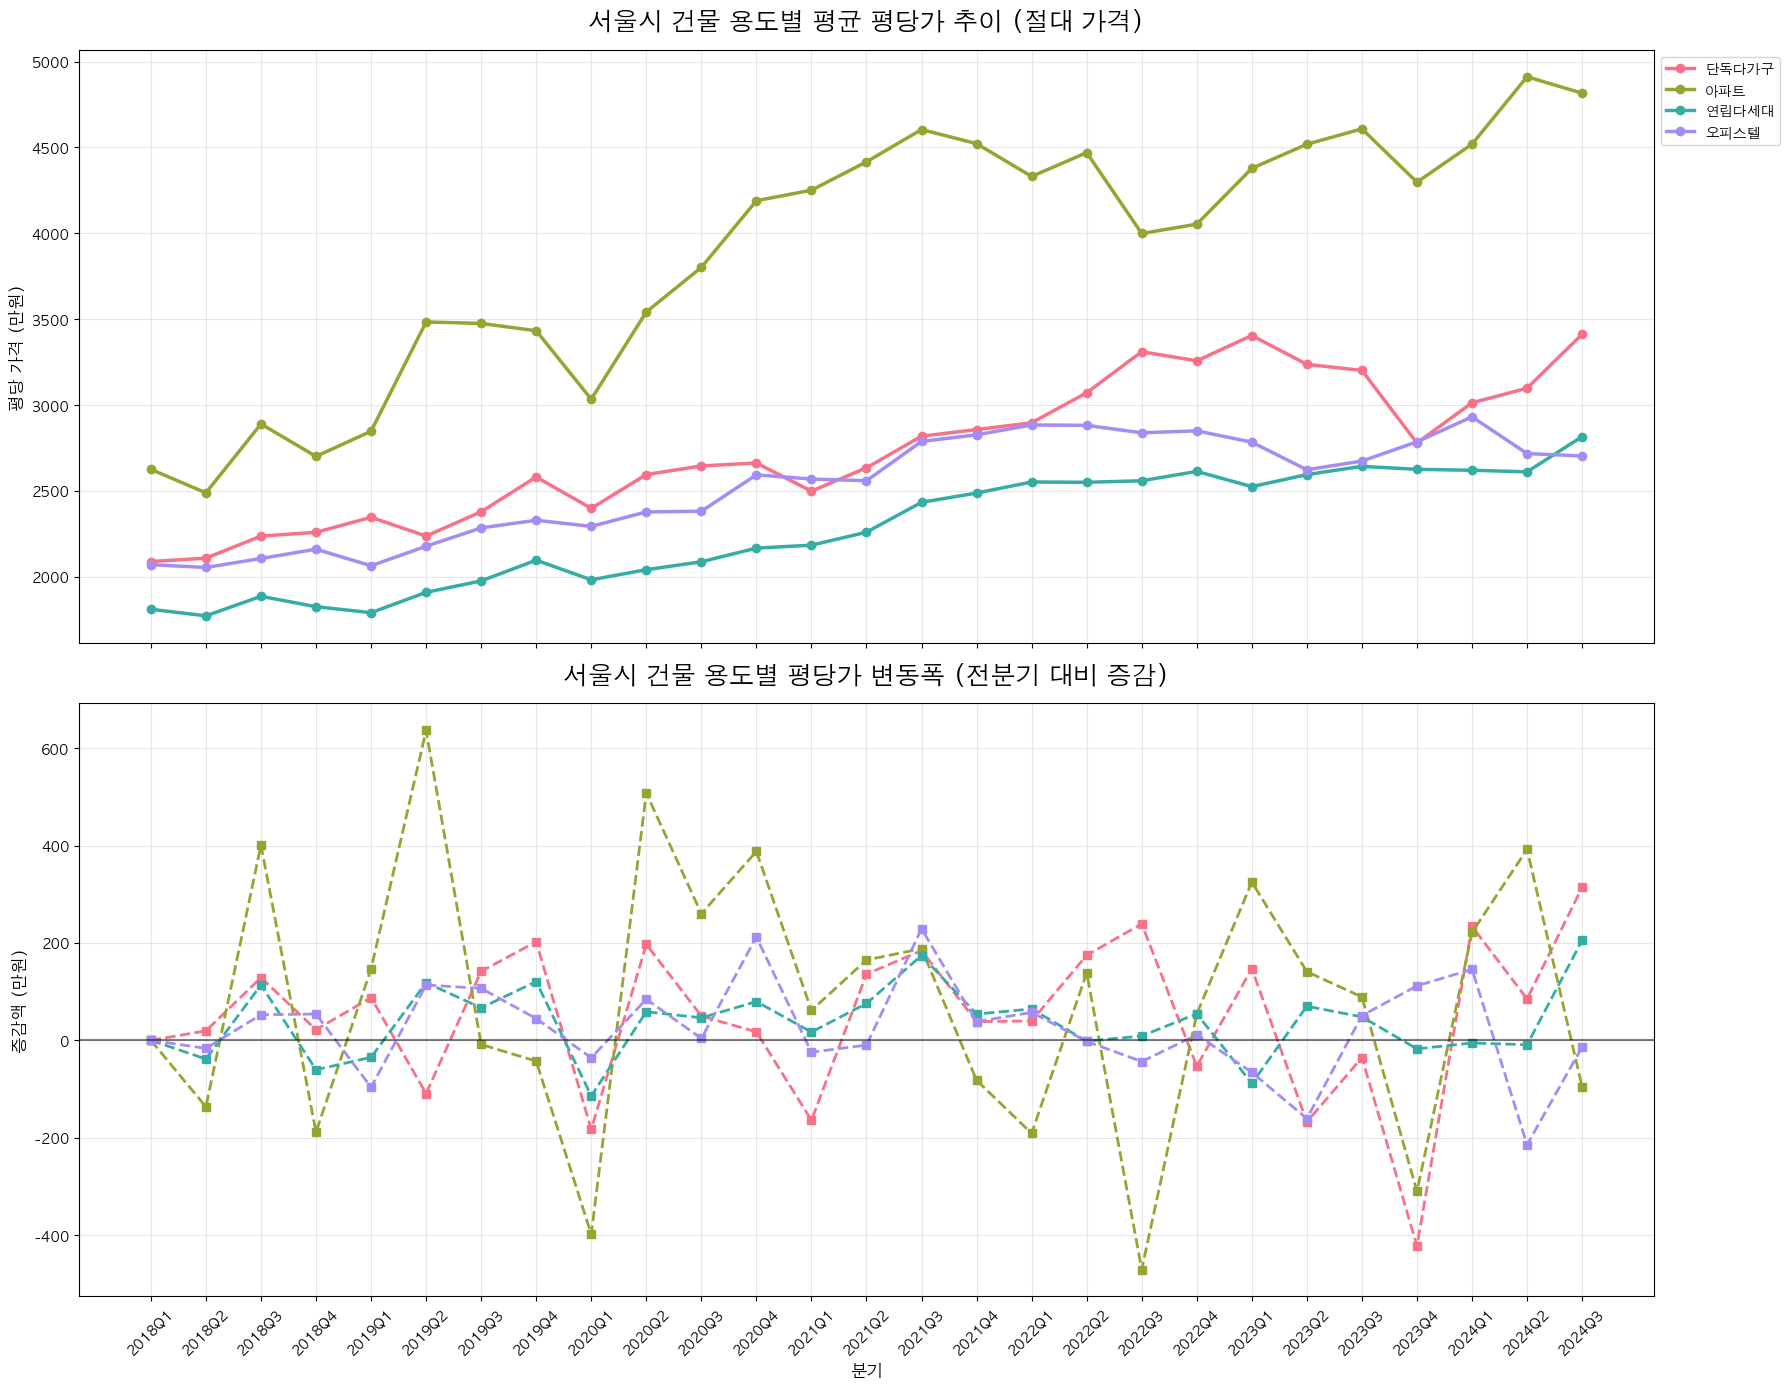

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_seoul_usage_comparison(dfm):
    # 1. 데이터 전처리: 건물 용도별, 분기별 평당가 평균 계산
    usage_stats = dfm.groupby(['QUARTER', 'BLDG_USG'])['AMT_PER_PYEONG'].mean().unstack()
    
    # 2. 변동폭(Diff) 계산: 전분기 대비 평당가 차이
    usage_diff = usage_stats.diff().fillna(0)

    # 3. 시각화 (2단 구성)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 14), sharex=True)
    
    # 용도별 고유 색상 설정
    usg_types = usage_stats.columns
    colors = sns.color_palette("husl", len(usg_types))

    # --- 상단: 평당가 자체의 추이 (Price Trend) ---
    for i, usg in enumerate(usg_types):
        ax1.plot(usage_stats.index, usage_stats[usg], marker='o', label=usg, color=colors[i], linewidth=2.5)
    
    ax1.set_title("서울시 건물 용도별 평균 평당가 추이 (절대 가격)", fontsize=18, fontweight='bold', pad=15)
    ax1.set_ylabel("평당 가격 (만원)", fontsize=12)
    ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax1.grid(True, alpha=0.3)

    # --- 하단: 평당가 변동폭 (Price Volatility / Diff) ---
    for i, usg in enumerate(usg_types):
        ax2.plot(usage_diff.index, usage_diff[usg], marker='s', label=usg, color=colors[i], linewidth=2, linestyle='--')
    
    ax2.axhline(0, color='black', linewidth=1.5, alpha=0.5) # 0선 (보합 기준)
    ax2.set_title("서울시 건물 용도별 평당가 변동폭 (전분기 대비 증감)", fontsize=18, fontweight='bold', pad=15)
    ax2.set_ylabel("증감액 (만원)", fontsize=12)
    ax2.set_xlabel("분기", fontsize=12)
    ax2.grid(True, alpha=0.3)

    # X축 라벨 정리
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 실행
plot_seoul_usage_comparison(df)

BLDG_USG,단독다가구,아파트,연립다세대,오피스텔
QUARTER,,,,
2018Q1,2088.761646,2625.204540,1810.804468,2070.547079
2018Q2,2108.204030,2488.644629,1772.429168,2054.049580
2018Q3,2236.906668,2889.332986,1886.149149,2106.519789
2018Q4,2258.703560,2700.912898,1825.737915,2160.510431
2019Q1,2346.294961,2847.335609,1790.830892,2064.164251
2019Q2,2236.927119,3483.581526,1909.295688,2177.682030
2019Q3,2378.520516,3475.025107,1975.934420,2284.402954
2019Q4,2580.932266,3432.275041,2096.559590,2329.091571
2020Q1,2398.171055,3033.958678,1982.377367,2293.184128


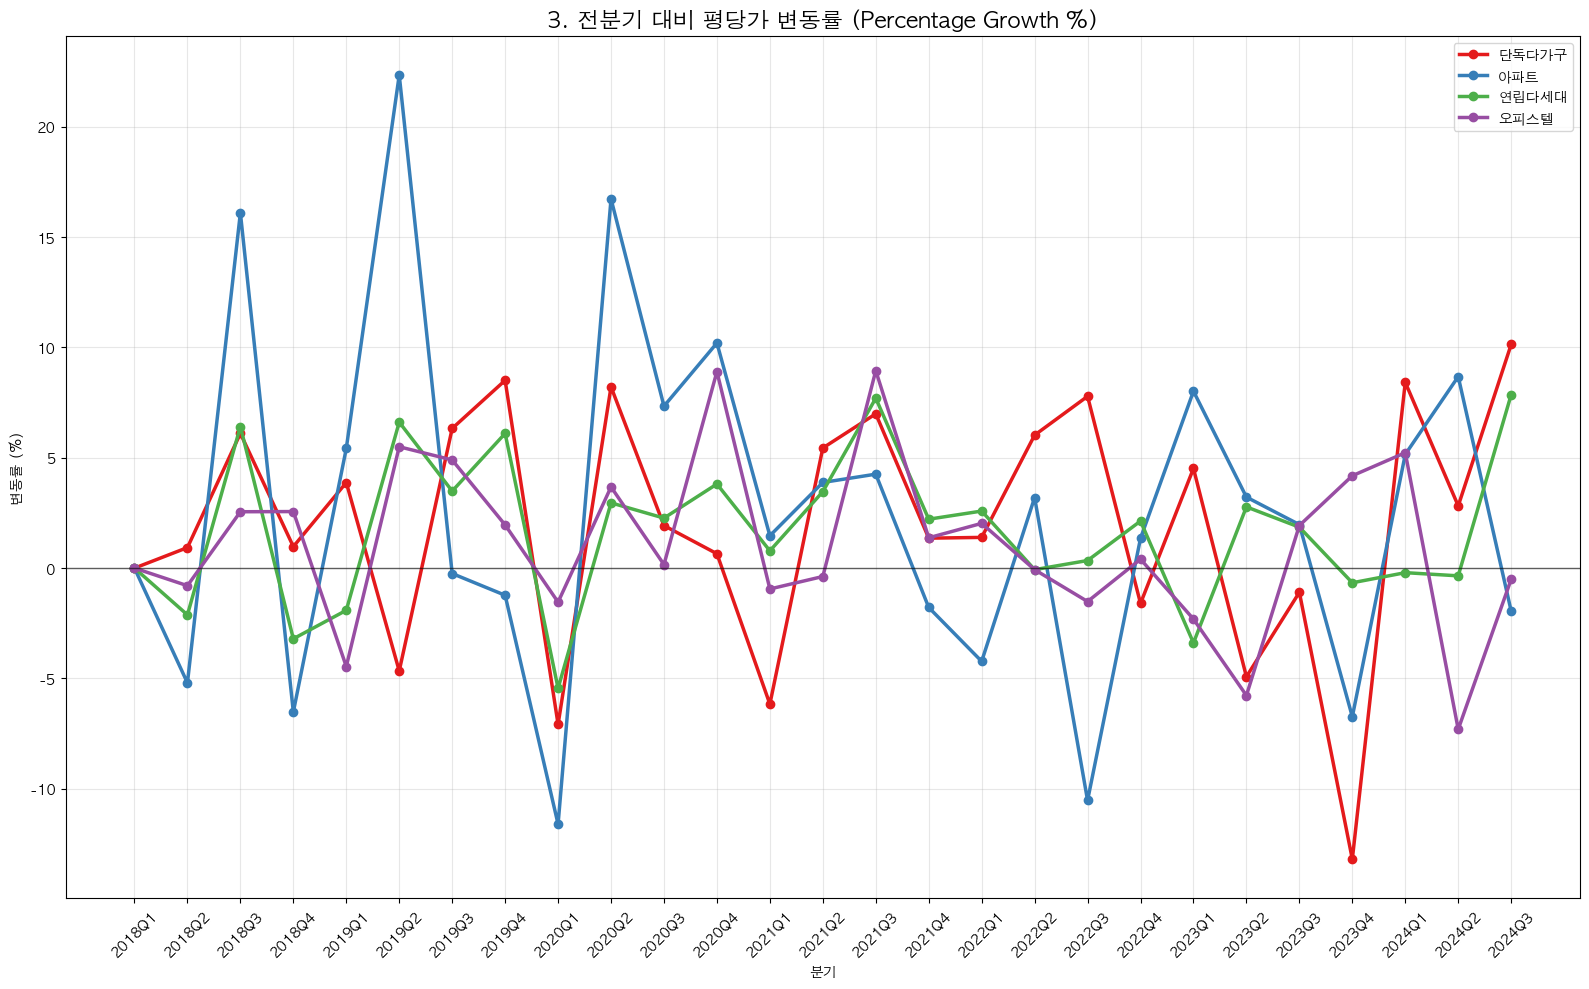

In [ ]:
# 1. 데이터 전처리: 건물 용도별, 분기별 평당가 평균 계산
usage_stats = df.groupby(['QUARTER', 'BLDG_USG'])['AMT_PER_PYEONG'].mean().unstack()

# 2. 지표 계산
usage_pct = usage_stats.pct_change().fillna(0) * 100  # 변동률 (%)

# 3. 시각화
plt.figure(figsize=(16,10))

# 건물 용도별로 하나씩...
usg_types = usage_stats.columns
colors = sns.color_palette("Set1", len(usg_types))

# --- 평당가 변동률 (Percentage Change) ---
for i, usg in enumerate(usg_types):
    # 아파트(수익률 핵심) 강조를 위해 선 두께 조절 가능
    line_width = 4 if usg == '아파트' else 2.5
    plt.plot(usage_pct.index, usage_pct[usg], marker='o', label=usg, color=colors[i], linewidth=line_width)

plt.axhline(0, color='black', linewidth=1.0, alpha=0.6) # 수익/손실 분기점
plt.title("전분기 대비 평당가 변동률 (Percentage Growth %)", fontsize=16, fontweight='bold')
plt.ylabel("변동률 (%)")
plt.xlabel("분기")
plt.grid(True, alpha=0.3)
plt.legend()

# X축 라벨 정리
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

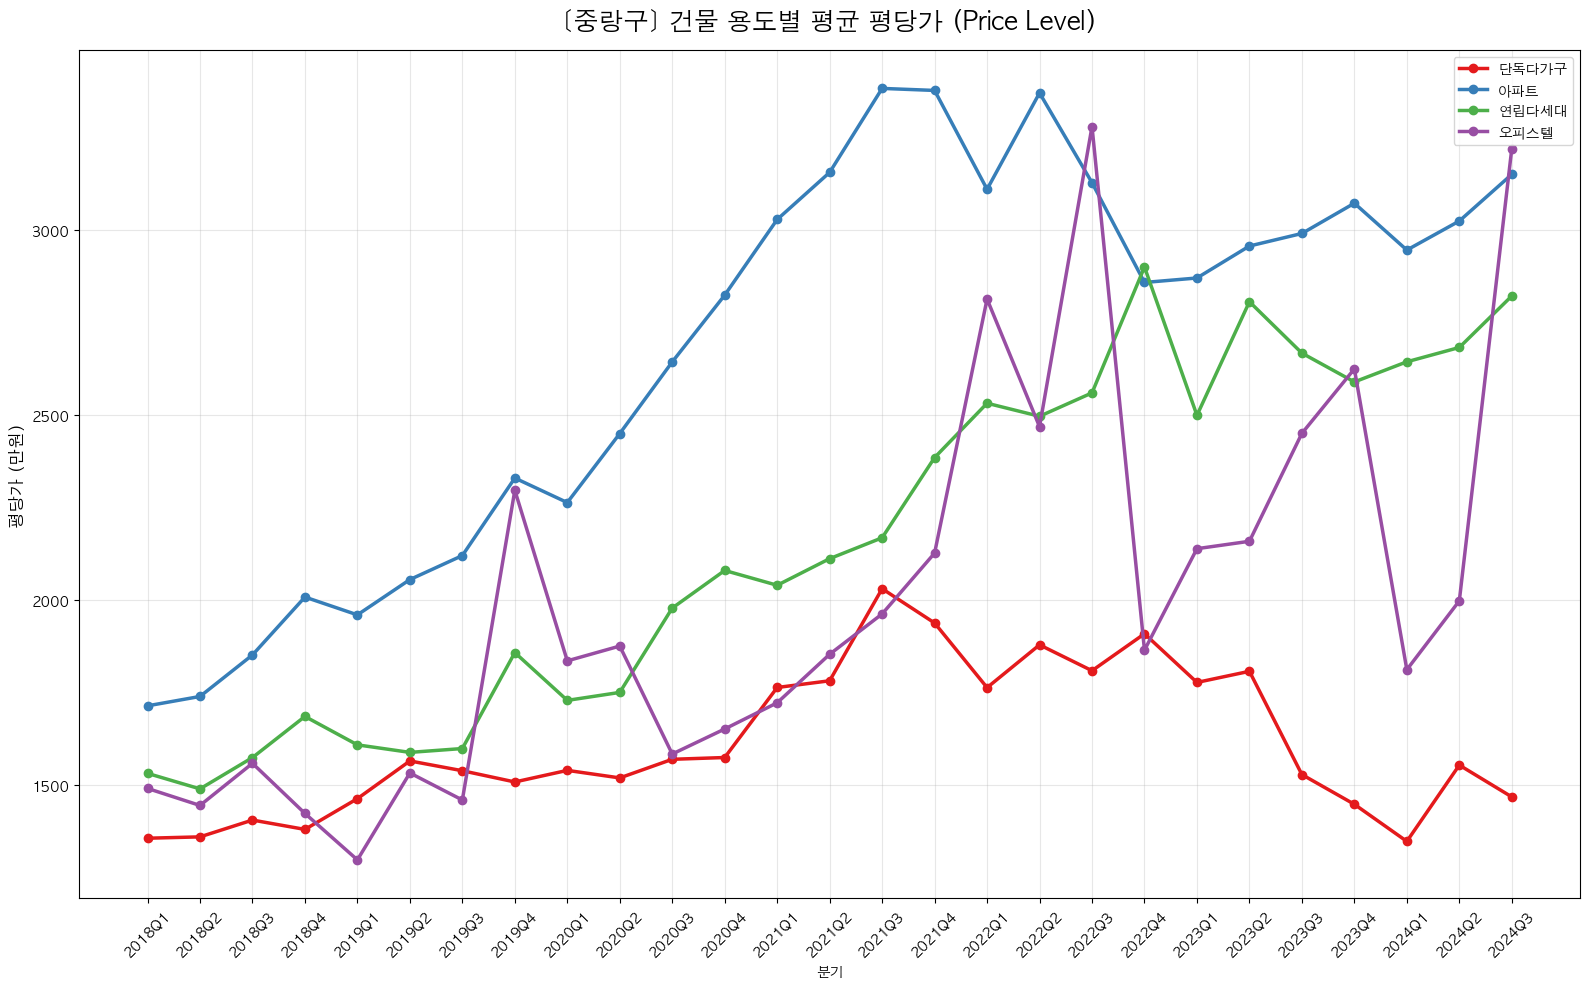

In [125]:
# 중랑구 데이터만 필터링
jn_df = df[df['CGG_NM'] == '중랑구'].copy()

# 데이터 전처리: 건물 용도별, 분기별 평당가 평균 계산
usage_stats = jn_df.groupby(['QUARTER', 'BLDG_USG'])['AMT_PER_PYEONG'].mean().unstack()

# 시각화
plt.figure(figsize=(16, 10))

# 용도별 색상 팔레트 (기존 분석과 통일감 유지)
usg_types = usage_stats.columns
colors = sns.color_palette("Set1", len(usg_types))

# --- 평당가 추이 (절대 가격) ---
for i, usg in enumerate(usg_types):
    plt.plot(usage_stats.index, usage_stats[usg], marker='o', label=usg, color=colors[i], linewidth=2.5)
plt.title("[중랑구] 건물 용도별 평균 평당가 (Price Level)", fontsize=18, fontweight='bold', pad=15)
plt.ylabel("평당가 (만원)", fontsize=12)
plt.xlabel("분기")
plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


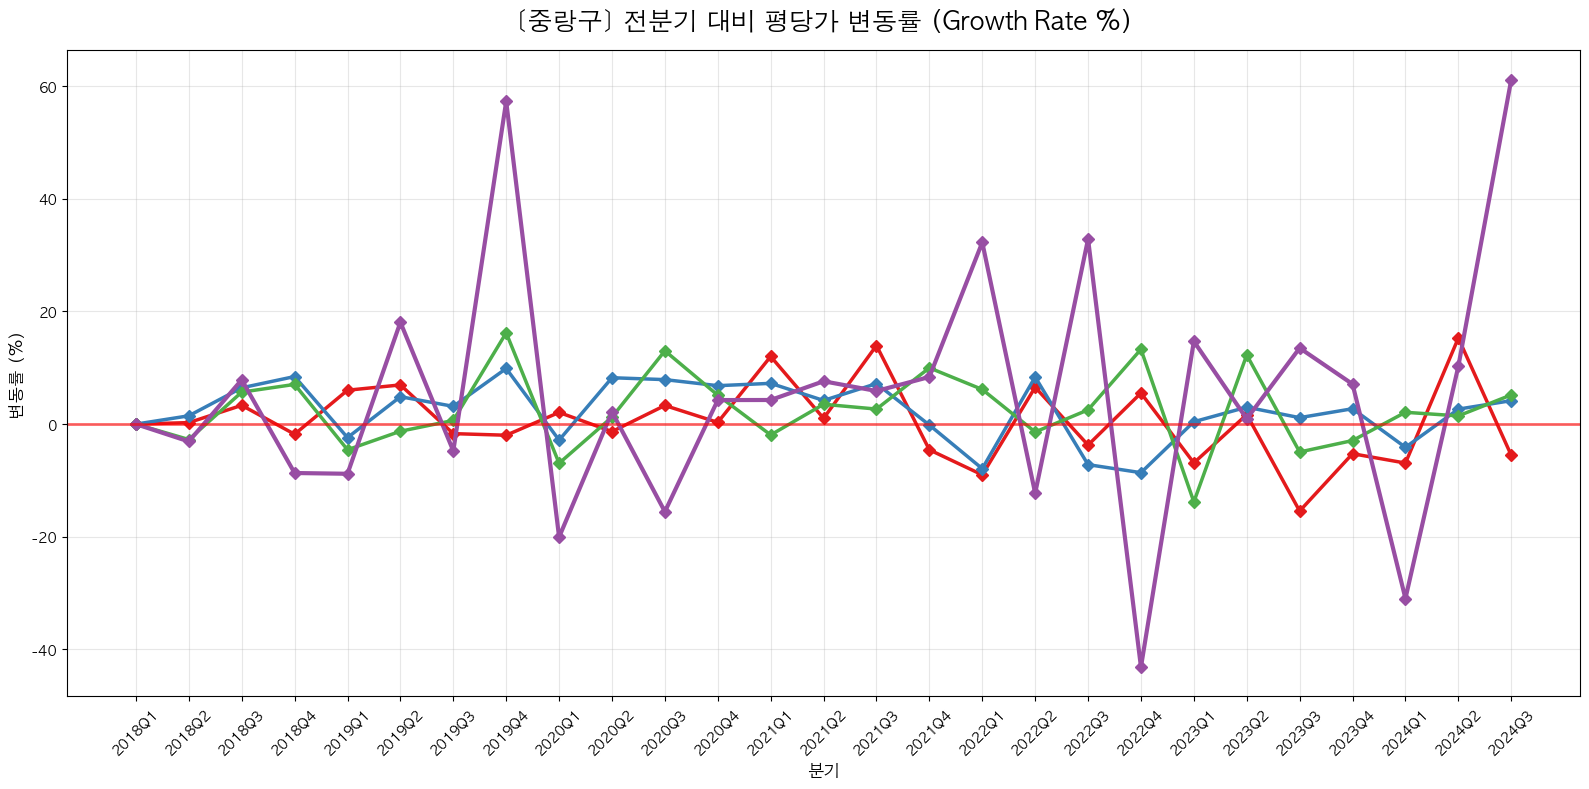

In [129]:
# 중랑구 데이터만 필터링
jn_df = df[df['CGG_NM'] == '중랑구'].copy()

# 데이터 전처리: 건물 용도별, 분기별 평당가 평균 계산
usage_stats = jn_df.groupby(['QUARTER', 'BLDG_USG'])['AMT_PER_PYEONG'].mean().unstack()

# 지표 계산
usage_pct = usage_stats.pct_change().fillna(0) * 100  # 변동률 (%)

# 시각화 
plt.figure(figsize=(16, 8))

# 용도별 색상 팔레트 (기존 분석과 통일감 유지)
usg_types = usage_stats.columns
colors = sns.color_palette("Set1", len(usg_types))

# --- 중랑구 평당가 변동률 (수익률 지표) ---
for i, usg in enumerate(usg_types):
    # 오피스텔(수익률 핵심) 강조를 위해 선 두께 조절 가능
    line_width = 3 if usg == '오피스텔' else 2.5
    plt.plot(usage_pct.index, usage_pct[usg], marker='D', label=usg, color=colors[i], linewidth=line_width)

plt.axhline(0, color='red', linewidth=2, alpha=0.6) # 수익/손실 분기점
plt.title("[중랑구] 전분기 대비 평당가 변동률 (Growth Rate %)", fontsize=18, fontweight='bold', pad=15)
plt.ylabel("변동률 (%)", fontsize=12)
plt.xlabel("분기", fontsize=12)
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [88]:
df2 = pd.read_csv('data/real_estate_clean_v2.csv', encoding='cp949')

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_98926/4156639617.py:1: DtypeWarning: Columns (12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('data/real_estate_clean_v2.csv', encoding='cp949')


In [89]:
df2['CTRT_DAY'] = pd.to_datetime(df2['CTRT_DAY'], errors="coerce")

In [90]:
# 1. 분기(Quarter) 컬럼 생성
df2['Quarter'] = df2['CTRT_DAY'].dt.quarter

In [101]:
df2['Q'] = df2['CTRT_YEAR'].astype(str) + 'Q' + df2['Quarter'].astype(str) 
df2['Q'].value_counts()

Q
2019Q4    54625
2018Q1    53269
2018Q3    49674
2020Q2    45960
2020Q3    41438
2020Q4    38848
2019Q3    37886
2020Q1    37797
2021Q2    36804
2021Q1    36124
2018Q2    31719
2021Q3    31314
2019Q2    28897
2024Q3    26330
2024Q2    25572
2022Q2    21965
2021Q4    21923
2018Q4    20649
2023Q3    18894
2023Q2    18419
2024Q1    17435
2019Q1    16949
2022Q1    16695
2023Q4    13926
2023Q1    13642
2022Q3    11852
2022Q4     8701
Name: count, dtype: int64

In [102]:
df2['QUARTER'].value_counts()

QUARTER
2019Q4    54625
2018Q1    53269
2018Q3    49674
2020Q2    45960
2020Q3    41438
2020Q4    38848
2019Q3    37886
2020Q1    37797
2021Q2    36804
2021Q1    36124
2018Q2    31719
2021Q3    31314
2019Q2    28897
2024Q3    26330
2024Q2    25572
2022Q2    21965
2021Q4    21923
2018Q4    20649
2023Q3    18894
2023Q2    18419
2024Q1    17435
2019Q1    16949
2022Q1    16695
2023Q4    13926
2023Q1    13642
2022Q3    11852
2022Q4     8701
Name: count, dtype: int64

      [종로구 vs 서울시 전체] 아파트 투자 백테스트 비교
1. 투자 기간 : 2022-2Q ~ 2024-3Q (10분기)
2. 매입 금액 : 10.0억 원
----------------------------------------------------------------
   구분        |      종로구      |     서울시 전체
----------------------------------------------------------------
3. 최종 금액   |  11.09억 (+1.09억) |  10.77억 (+0.77억)
4. 누적 수익률 |      10.91 %       |       7.75 %
5. CAGR (연)   |       4.23 %       |       3.03 %
6. MDD (낙폭)  |     -32.33 %       |     -10.53 %
----------------------------------------------------------------
 * 비교 결과: 종로구 수익률이 서울 평균보다 높음



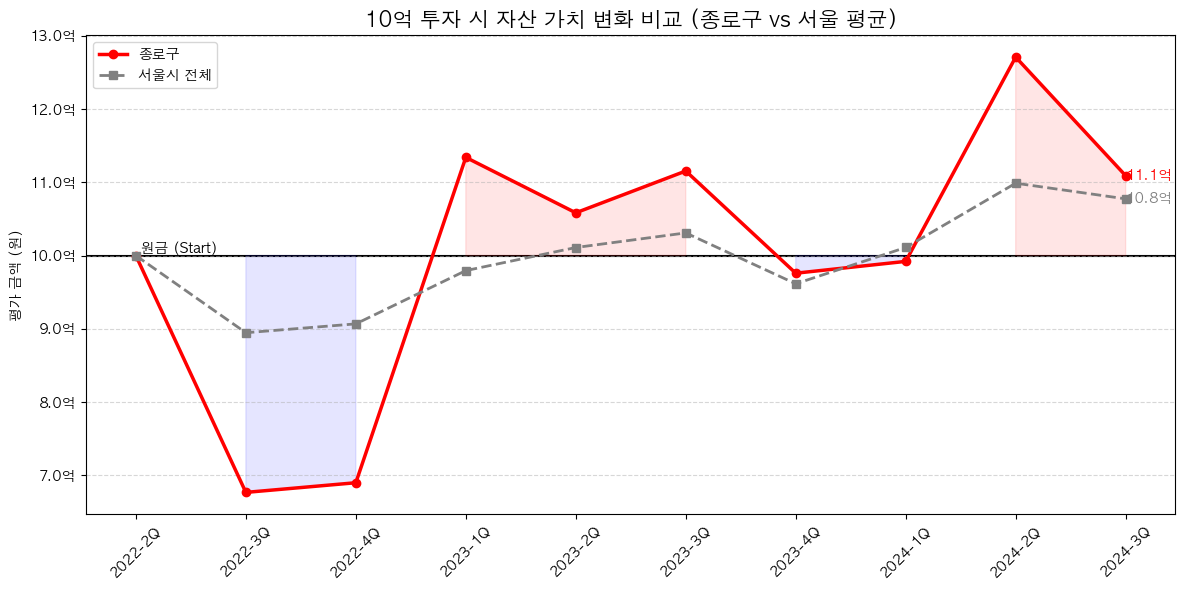

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def run_real_estate_backtest_vs_seoul(target_gu, bldg_type, start_year, start_Quarter, initial_capital, duration_Quarters):
    # 1. 기간 설정
    period_list = []
    current_y, current_q = start_year, start_Quarter
    
    for _ in range(duration_Quarters + 1):
        period_list.append((current_y, current_q))
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    target_years = sorted(list(set([y for y, q in period_list])))
    target_labels = [f"{y}-{q}Q" for y, q in period_list]
    
    # 2. 데이터 추출
    # (1) 타겟 자치구
    mask_gu = (
        (df2['CTRT_YEAR'].isin(target_years)) & 
        (df2['BLDG_USG'] == bldg_type) &
        (df2['CGG_NM'] == target_gu)
    )
    df_gu = df2.loc[mask_gu].copy()
    
    # (2) 서울시 전체 (비교군)
    mask_seoul = (
        (df2['CTRT_YEAR'].isin(target_years)) & 
        (df2['BLDG_USG'] == bldg_type)
    )
    df_seoul = df2.loc[mask_seoul].copy()
    
    if df_gu.empty or df_seoul.empty:
        print("데이터가 부족합니다.")
        return

    # 공통 전처리 함수
    def get_price_series(temp_df, group_cols):
        temp_df['YR_Q_STR'] = temp_df['CTRT_YEAR'].astype(str) + '-' + temp_df['Quarter'].astype(str) + 'Q'
        series = temp_df.groupby(['CTRT_YEAR', 'Quarter'])['AMT_PER_AREA'].mean()
        pdf = pd.DataFrame(series).reset_index()
        pdf['Label'] = pdf['CTRT_YEAR'].astype(str) + '-' + pdf['Quarter'].astype(str) + 'Q'
        pdf = pdf[pdf['Label'].isin(target_labels)]
        pdf = pdf.set_index('Label').reindex(target_labels).dropna()
        return pdf

    price_gu = get_price_series(df_gu, ['CTRT_YEAR', 'Quarter'])
    price_seoul = get_price_series(df_seoul, ['CTRT_YEAR', 'Quarter'])
    
    # 데이터가 중간에 끊겼으면 자르기 (교집합 기간만 비교)
    common_idx = price_gu.index.intersection(price_seoul.index)
    price_gu = price_gu.loc[common_idx]
    price_seoul = price_seoul.loc[common_idx]
    
    # 3. 자산 가치 변동 및 지표 계산 함수
    def calc_metrics(price_df, capital):
        start_p = price_df['AMT_PER_AREA'].iloc[0]
        portfolio = (price_df['AMT_PER_AREA'] / start_p) * capital
        
        final_val = portfolio.iloc[-1]
        ret = (final_val / capital - 1) * 100
        
        years = len(portfolio) / 4
        cagr = ((final_val / capital) ** (1/years) - 1) * 100
        
        # MDD
        run_max = portfolio.cummax()
        dd = (portfolio / run_max - 1) * 100
        mdd = dd.min()
        
        # Best/Worst Year (단순화: 1년 4분기 전 대비 변동률 중 Max/Min)
        if len(portfolio) >= 5:
            # YoY (전년 동기 대비) Rolling
            yoy = portfolio.pct_change(4) * 100
            best_y = yoy.max()
            worst_y = yoy.min()
        else:
            best_y, worst_y = 0, 0
            
        return portfolio, final_val, ret, cagr, mdd, best_y, worst_y

    # 계산
    pf_gu, val_gu, ret_gu, cagr_gu, mdd_gu, best_gu, worst_gu = calc_metrics(price_gu, initial_capital)
    pf_seoul, val_seoul, ret_seoul, cagr_seoul, mdd_seoul, best_seoul, worst_seoul = calc_metrics(price_seoul, initial_capital)
    
    profit_gu = val_gu - initial_capital
    profit_seoul = val_seoul - initial_capital
    
    # --- [결과 텍스트 출력] ---
    print(f"================================================================")
    print(f"      [{target_gu} vs 서울시 전체] {bldg_type} 투자 백테스트 비교")
    print(f"================================================================")
    print(f"1. 투자 기간 : {common_idx[0]} ~ {common_idx[-1]} ({len(common_idx)}분기)")
    print(f"2. 매입 금액 : {initial_capital/100000000:.1f}억 원")
    print(f"----------------------------------------------------------------")
    print(f"   구분        |      {target_gu}      |     서울시 전체")
    print(f"----------------------------------------------------------------")
    print(f"3. 최종 금액   |  {val_gu/100000000:.2f}억 (+{profit_gu/100000000:.2f}억) |  {val_seoul/100000000:.2f}억 (+{profit_seoul/100000000:.2f}억)")
    print(f"4. 누적 수익률 |     {ret_gu:6.2f} %       |     {ret_seoul:6.2f} %")
    print(f"5. CAGR (연)   |     {cagr_gu:6.2f} %       |     {cagr_seoul:6.2f} %")
    print(f"6. MDD (낙폭)  |     {mdd_gu:6.2f} %       |     {mdd_seoul:6.2f} %")
    print(f"----------------------------------------------------------------")
    print(f" * 비교 결과: {target_gu} 수익률이 서울 평균보다 {'높음' if ret_gu > ret_seoul else '낮음'}")
    print(f"================================================================\n")
    
    # --- [시각화] ---
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # (1) 데이터 플로팅
    ax.plot(pf_gu.index, pf_gu, color='red', linewidth=2.5, marker='o', label=f'{target_gu}')
    ax.plot(pf_seoul.index, pf_seoul, color='gray', linewidth=2, linestyle='--', marker='s', label='서울시 전체')
    
    # (2) 기준선 (원금) 강조 -> 'y축의 0을 원금으로 대체' 효과
    # 실제 Y축 값을 바꾸기보다, 원금 선을 X축처럼 굵게 그림
    ax.axhline(initial_capital, color='black', linewidth=1.5, linestyle='-', zorder=1)
    ax.text(pf_gu.index[0], initial_capital, " 원금 (Start)", va='bottom', fontweight='bold')
    
    # (3) 영역 채우기 (원금 기준 수익/손실)
    ax.fill_between(pf_gu.index, pf_gu, initial_capital, where=(pf_gu >= initial_capital), color='red', alpha=0.1)
    ax.fill_between(pf_gu.index, pf_gu, initial_capital, where=(pf_gu < initial_capital), color='blue', alpha=0.1)
    
    ax.set_title(f"10억 투자 시 자산 가치 변화 비교 ({target_gu} vs 서울 평균)", fontsize=15)
    ax.set_ylabel("평가 금액 (원)")
    
    # Y축 포맷 (억 단위)
    def billions(x, pos):
        return f'{x*1e-8:.1f}억'
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(billions))
    
    # 최종 금액 라벨링
    ax.text(pf_gu.index[-1], pf_gu.iloc[-1], f"{pf_gu.iloc[-1]/1e8:.1f}억", color='red', fontweight='bold', ha='left', va='center')
    ax.text(pf_seoul.index[-1], pf_seoul.iloc[-1], f"{pf_seoul.iloc[-1]/1e8:.1f}억", color='gray', fontweight='bold', ha='left', va='center')

    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 실행
run_real_estate_backtest_vs_seoul("종로구", "아파트", 2022, 2, 1000000000, 10)